# Turbulence synthesis: quantile ψ vs generalized-Gaussian ψ potential

This notebook runs the same 1D turbulence synthesis experiment twice:

1. **Baseline quantile model**
   ```python
   ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real',
    'Scalar_psi_quantile_confine', 'Scalar_morlet_quantile_confine']
   ```

2. **Generalized-Gaussian ψ model**
   ```python
   ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real',
    'Scalar_psi_generalized_gaussian', 'Scalar_morlet_generalized_gaussian']
   ```

The two runs are saved under different configuration names. The generalized-Gaussian run appends
`_generalized_gauss` to the saved sample name.


In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [2]:
def split_periodize_reshape(Data, n1):
    """
    Splits Data into non-overlapping subseries of length n1 along the last axis,
    discards the end if not divisible, periodizes each subseries, and reshapes
    the output to [batch * num_subseries, channels, n1].
    """
    num_subseries = Data.size(-1) // n1
    Data_sub = Data[:, :, :num_subseries * n1]
    Data_sub = Data_sub.unfold(-1, n1, n1)

    first = Data_sub[..., 0:1]
    last = Data_sub[..., -1:]
    a = (last - first) / (n1 - 1)
    b = first
    x = torch.arange(n1, device=Data.device, dtype=Data.dtype)
    linear = a * x + b 
    Data_periodized = Data_sub - linear 
    Data_periodized = Data_periodized + first 

    batch, channels, _, _ = Data_periodized.shape
    return Data_periodized.reshape(batch * num_subseries, channels, n1)

## Data preprocessing

In [3]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
n1 = 1024
Data = split_periodize_reshape(Data, n1)

# Same preprocessing as in the original notebook.
for j in range(3):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:10000]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape)


Data shape after preprocessing: torch.Size([10000, 1, 128])
x1 shape: torch.Size([10000, 1, 128])


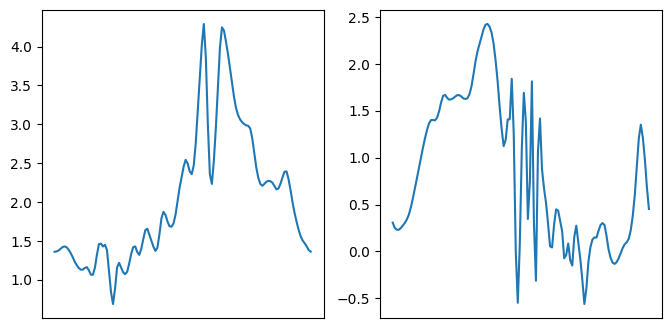

In [4]:
plot_time_series_row(x1, 2)


## Shared model/SDE parameters

In [5]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')

J = 7 # why 6 and not 7? 
Q = 3

filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

interpolant = 'Cos'
nt = 5000      # originally 50000
t = 1 - (1 - torch.linspace(0, 1, nt + 1))**2
sigma = 3.5

nb_workers = x1.shape[0]
nb_interpolants = x1.shape[0]
batch_size = x1.shape[0] // 16
regularization = 1e-1

base_config = f'turbulence_synthesis_{M}_J_{J}_Q_{Q}_sigma_{sigma}'
print('base_config:', base_config)


(B, C, T) = (10000, 1, 128).
base_config: turbulence_synthesis_128_J_7_Q_3_sigma_3.5


## Define the two experiments

In [6]:
experiments = {
    'coshgt_psi': {
        'label': 'CoshGt ψ',
        'suffix': f'_CoshGt_nt{nt}_n1_{x1.shape[0]}_scattering_Q3_and_Q1',
        'terms': [
            'Scattering_Second_Order',
            'Scattering_Fourth_Order_Real',
            'Scalar_psi_coshgt',
            'Scalar_morlet_coshgt',
        ],
    },

}

for key, exp in experiments.items():
    exp['config'] = base_config + exp['suffix']
    print(key, '->', exp['config'])


coshgt_psi -> turbulence_synthesis_128_J_7_Q_3_sigma_3.5_CoshGt_nt5000_n1_10000_scattering_Q3_and_Q1


## Run or load an experiment

Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.


In [7]:
FORCE_RERUN = False
SAVE_AUX_MOMENTS = True

def aux_path(config):
    return root.parent / f'{config}_aux_moments.pt'


def try_load_experiment(config):
    """Try loading saved SDE outputs and auxiliary moment-matching data."""
    try:
        xt, theta_t, dH_t_bound, t_loaded = load_results(root.parent, config)
        out = {
            'xt': xt.to(device) if torch.is_tensor(xt) else xt,
            'theta_t': theta_t,
            'dH_t_bound': dH_t_bound,
            't': t_loaded.to(device) if torch.is_tensor(t_loaded) else t_loaded,
            'loaded': True,
        }
        ap = aux_path(config)
        if ap.exists():
            aux = torch.load(ap, map_location=device)
            out.update(aux)
        else:
            out['barphi_e'] = None
            out['barphi_p'] = None
        return out
    except Exception as e:
        print(f'Could not load {config}: {e}')
        return None


def run_experiment(exp, force_rerun=False):
    config = exp['config']
    terms = exp['terms']

    if not force_rerun:
        loaded = try_load_experiment(config)
        if loaded is not None:
            print(f'Loaded existing results for {config}')
            return loaded

    print(f'Running experiment: {config}')
    print('terms:', terms)

    potentials = get_1d_potentials(
        terms,
        J,
        filters,
        Q,
        filters_Q,
        filters_Phi,
        scalar_param=None,
        parallel=False,
    )

    Solver = SDE(
        x1,
        nb_workers,
        nb_interpolants,
        t,
        sigma,
        potentials,
        batch_size,
        device=device,
        regularization=regularization,
        interpolant=interpolant,
    )

    xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

    save_results(xt, theta_t, dH_t_bound, t, root.parent, config)

    if SAVE_AUX_MOMENTS:
        torch.save(
            {
                'barphi_e': barphi_e.detach().cpu(),
                'barphi_p': barphi_p.detach().cpu(),
            },
            aux_path(config),
        )

    return {
        'xt': xt,
        'theta_t': theta_t,
        'dH_t_bound': dH_t_bound,
        't': t,
        'barphi_e': barphi_e,
        'barphi_p': barphi_p,
        'loaded': False,
    }


## Run both experiments

In [8]:
results = {}

for key, exp in experiments.items():
    results[key] = run_experiment(exp, force_rerun=FORCE_RERUN)
    print('-' * 80)


Could not load turbulence_synthesis_128_J_7_Q_3_sigma_3.5_CoshGt_nt5000_n1_10000_scattering_Q3_and_Q1: [Errno 2] No such file or directory: '/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/saved_results/samples/turbulence_synthesis_128_J_7_Q_3_sigma_3.5_CoshGt_nt5000_n1_10000_scattering_Q3_and_Q1'
Running experiment: turbulence_synthesis_128_J_7_Q_3_sigma_3.5_CoshGt_nt5000_n1_10000_scattering_Q3_and_Q1
terms: ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real', 'Scalar_psi_coshgt', 'Scalar_morlet_coshgt']
Signal detected as 1D: (B, C, T) = (625, 1, 128).
The model has 640 potentials.
[coshGT][ch 0] [tempered]  b=0.913  t=2.200  a=0.0020  x0=0.00054  (kappa=a*t=0.0043)
[coshGT][ch 1] [tempered]  b=0.698  t=2.177  a=0.0050  x0=0.00068  (kappa=a*t=0.0109)


/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/../codes/potentials/potentials_1d.py:1132: RuntimeWarning: divide by zero encountered in log
  lx = np.log(np.maximum(np.abs(x), 1e-300))


[coshGT][ch 2] [tempered]  b=0.630  t=2.212  a=0.0137  x0=0.00168  (kappa=a*t=0.0302)
[coshGT][ch 3] [tempered]  b=0.702  t=2.230  a=0.0293  x0=0.00376  (kappa=a*t=0.0653)
[coshGT][ch 4] [tempered]  b=0.853  t=2.233  a=0.0550  x0=0.00731  (kappa=a*t=0.1228)
[coshGT][ch 5] [tempered]  b=1.003  t=2.188  a=0.1037  x0=0.01264  (kappa=a*t=0.2268)
[coshGT][ch 6] [tempered]  b=1.248  t=2.138  a=0.1701  x0=0.01974  (kappa=a*t=0.3636)
[coshGT][ch 7] [tempered]  b=1.458  t=2.017  a=0.2594  x0=0.02763  (kappa=a*t=0.5231)
[coshGT][ch 8] [tempered]  b=1.015  t=1.032  a=0.8691  x0=0.03576  (kappa=a*t=0.8972)
[coshGT][ch 9] [tempered]  b=1.016  t=0.662  a=1.5250  x0=0.04357  (kappa=a*t=1.0092)
[coshGT][ch 10] [tempered]  b=1.014  t=0.711  a=1.4745  x0=0.05110  (kappa=a*t=1.0477)
[coshGT][ch 11] [tempered]  b=2.300  t=1.462  a=0.6547  x0=0.05862  (kappa=a*t=0.9573)
[coshGT][ch 12] [tempered]  b=1.020  t=0.765  a=1.4425  x0=0.06727  (kappa=a*t=1.1031)
[coshGT][ch 13] [tempered]  b=2.760  t=1.590  a=0.6

5000it [4:19:53,  3.12s/it]


--------------------------------------------------------------------------------


## Checking thetas

=== Experiment: coshgt_psi ===
torch.Size([2001, 94])


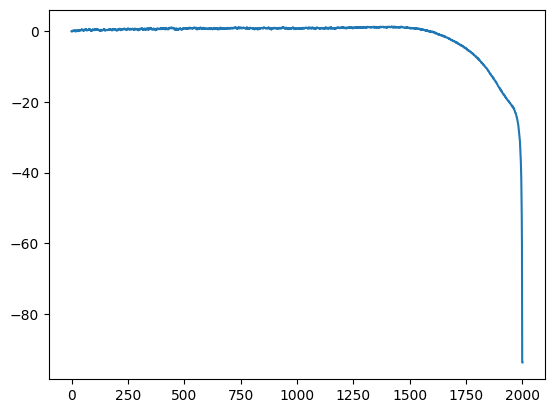

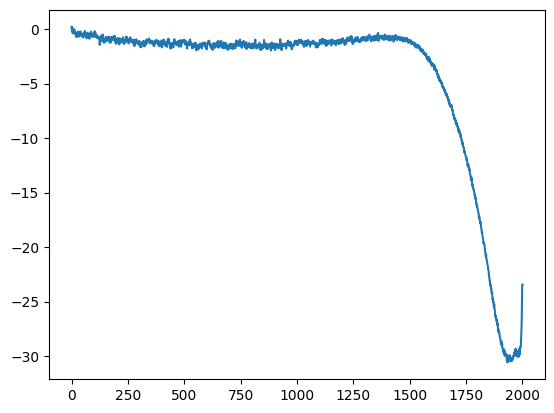

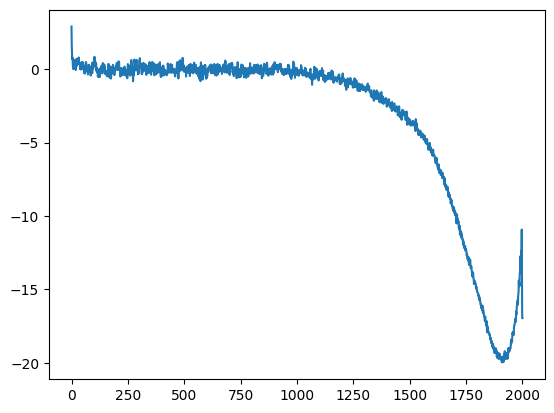

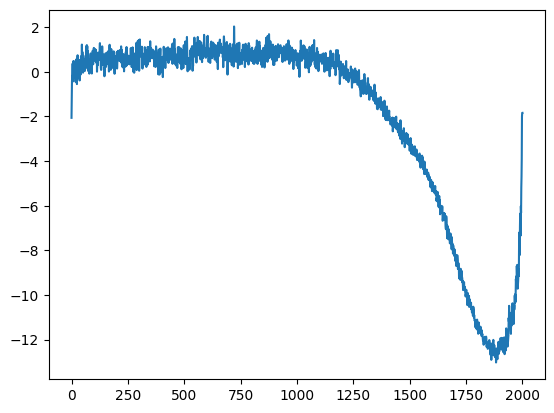

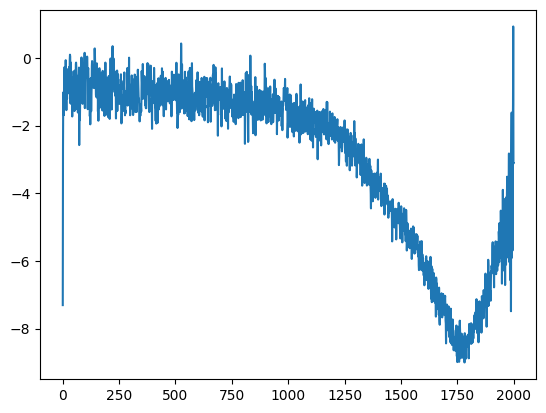

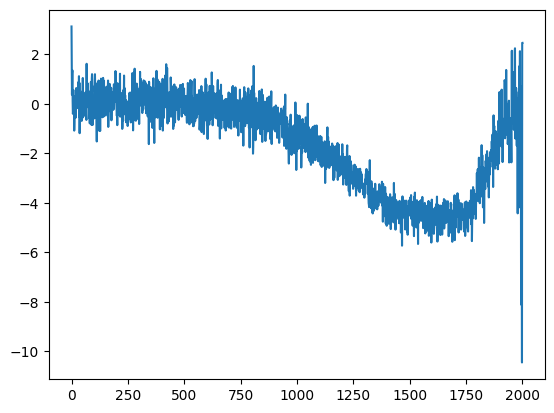

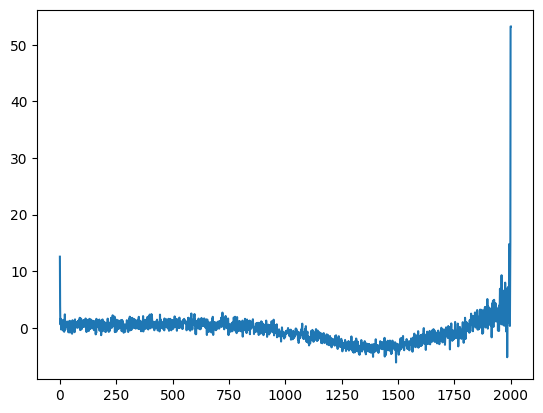

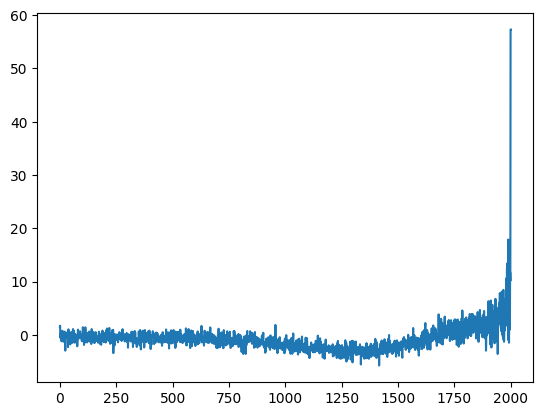

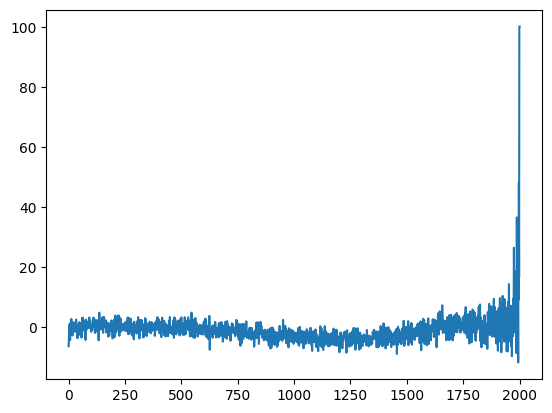

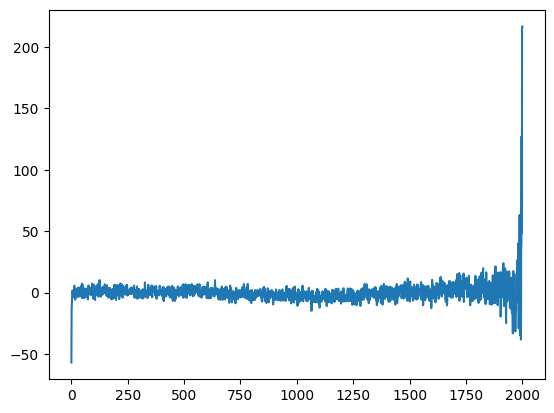

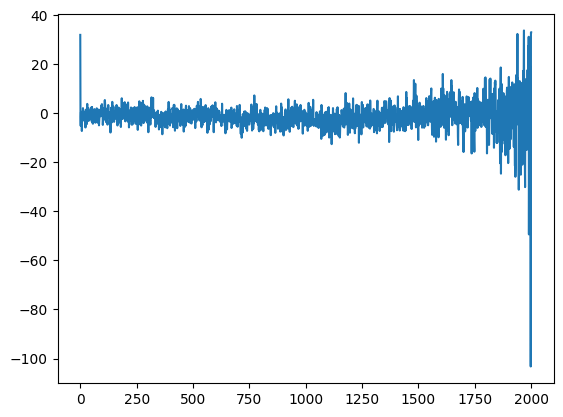

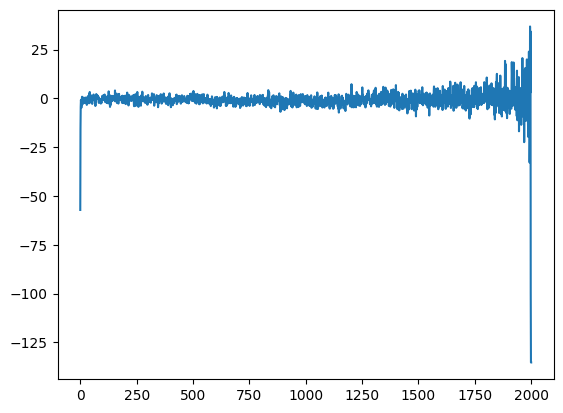

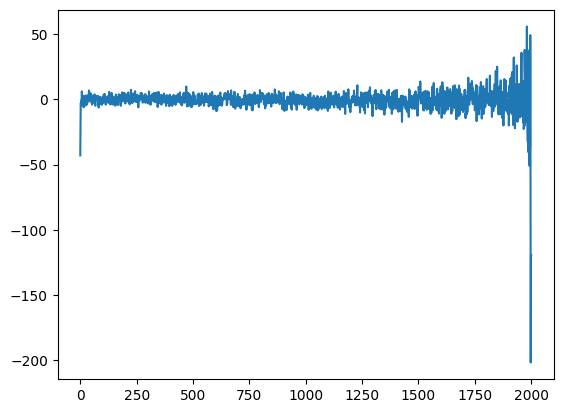

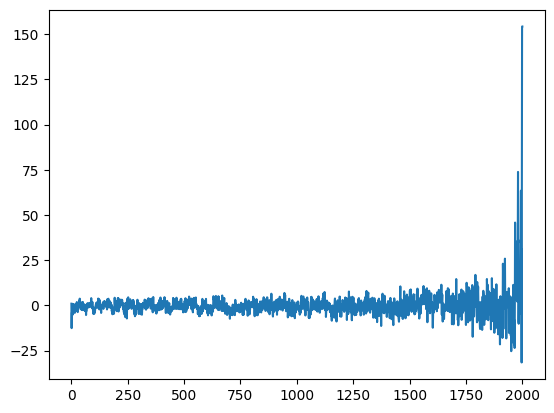

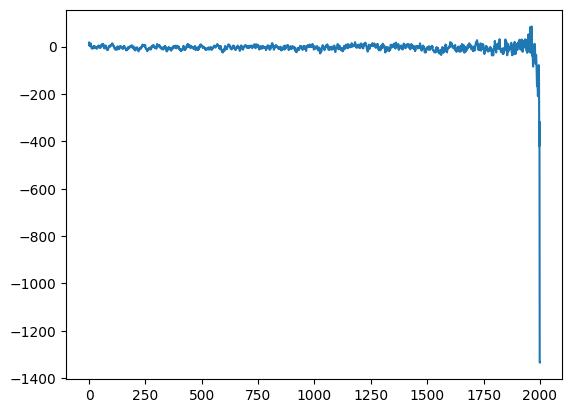

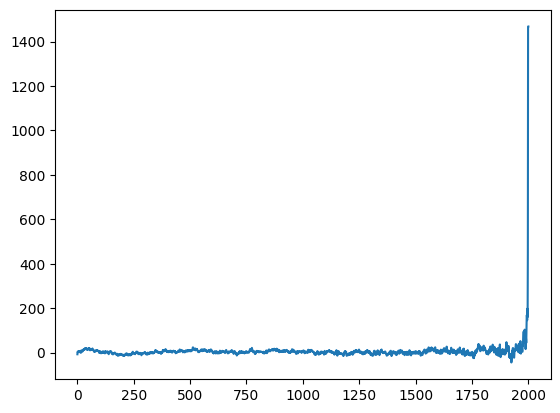

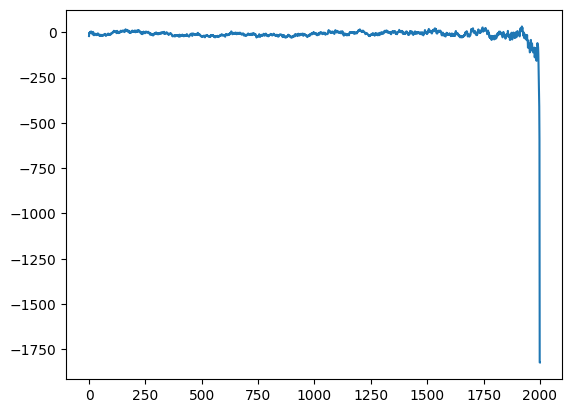

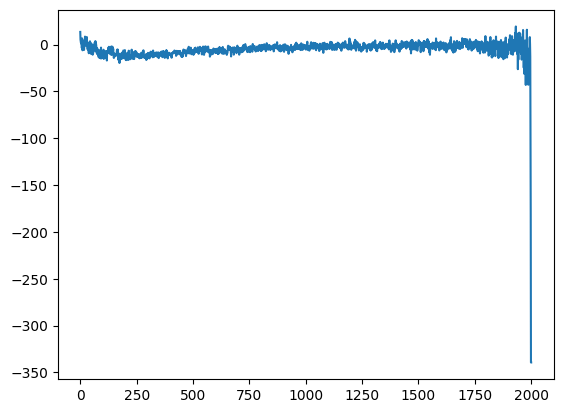

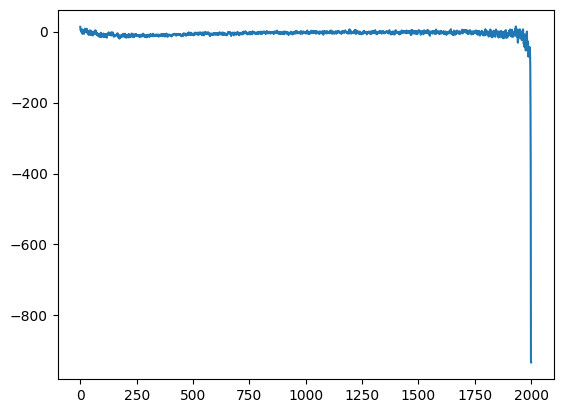

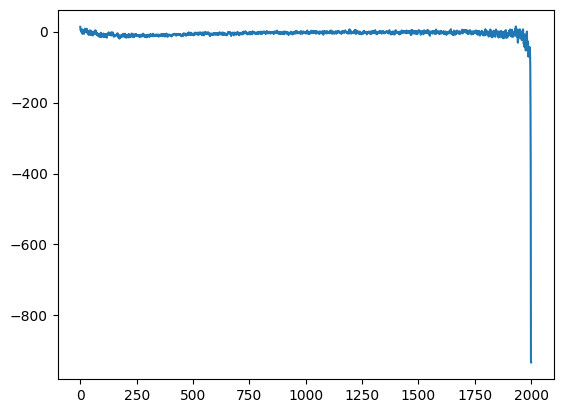

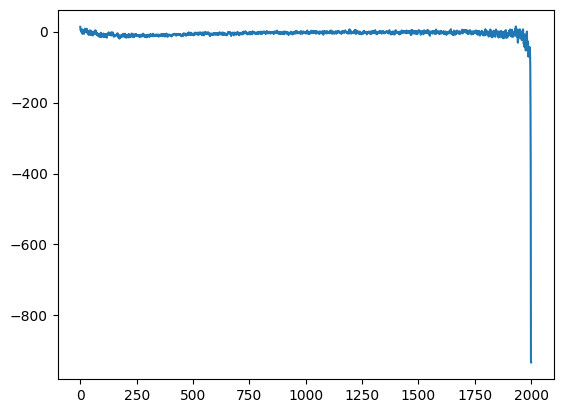

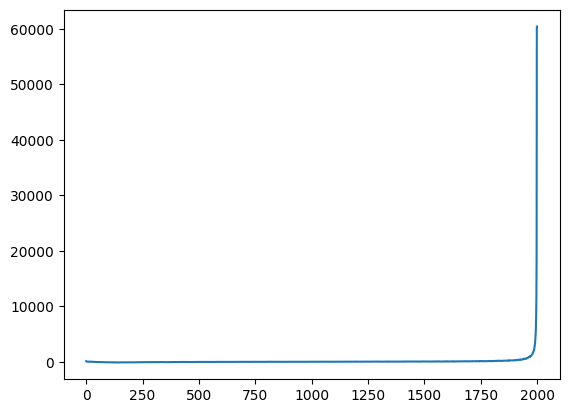

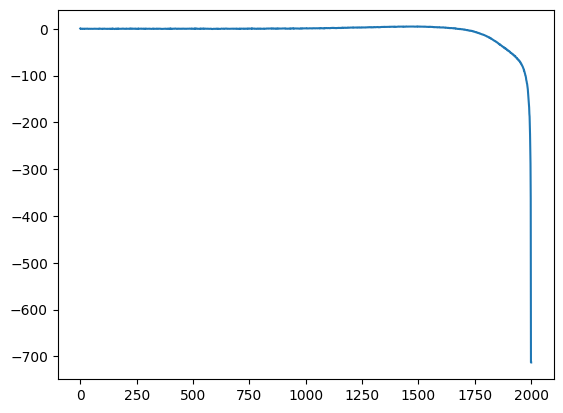

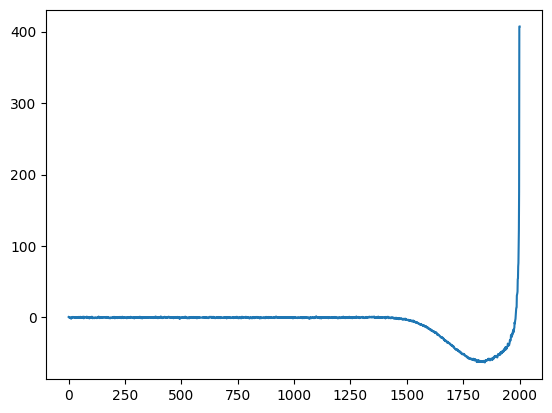

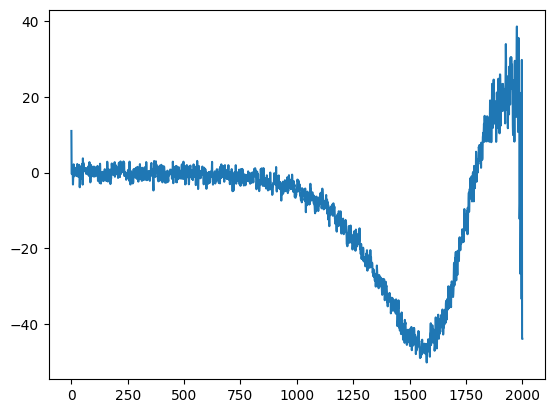

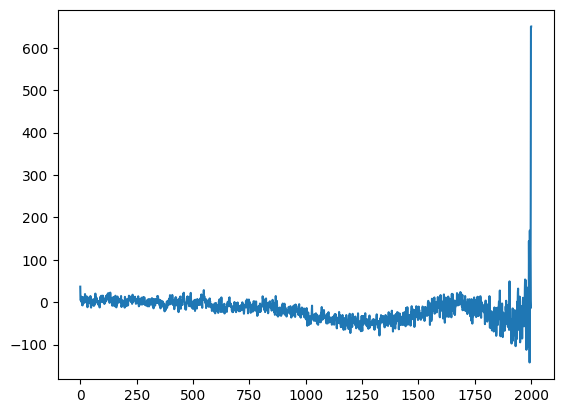

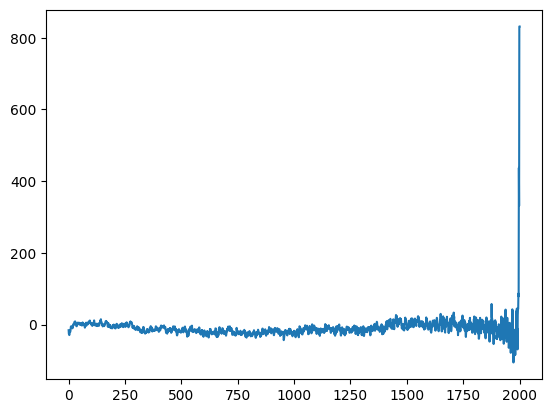

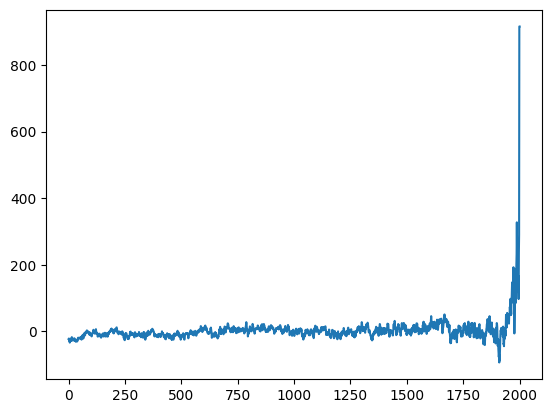

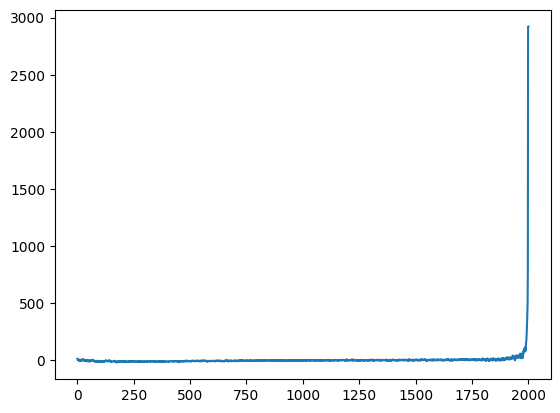

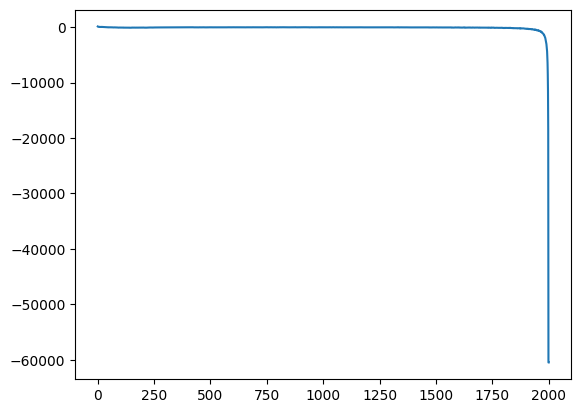

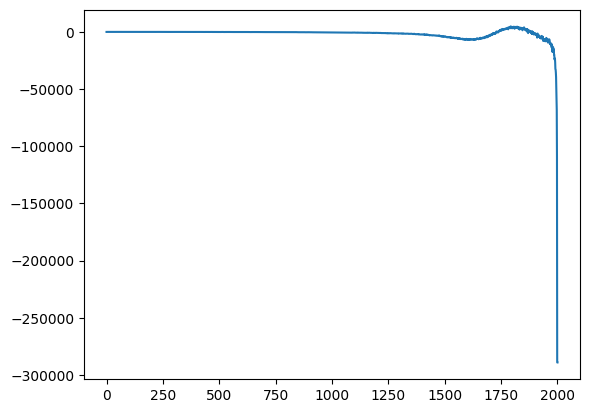

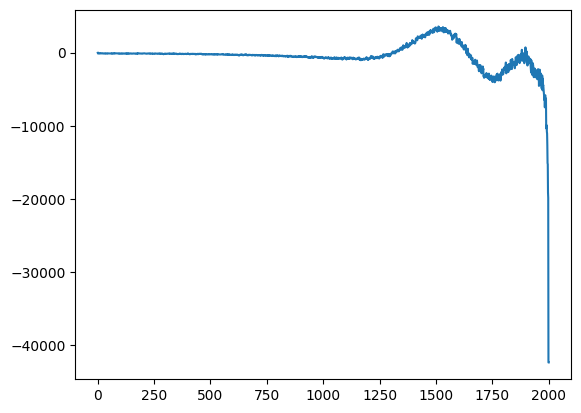

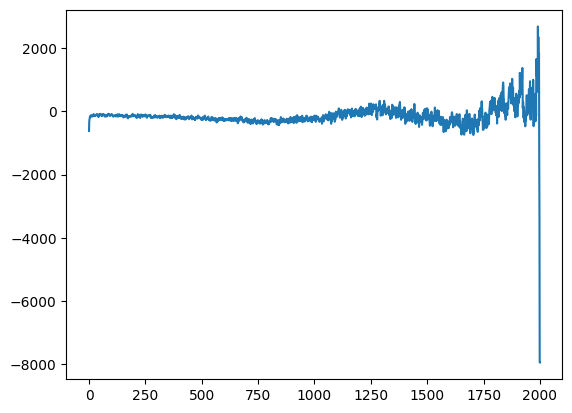

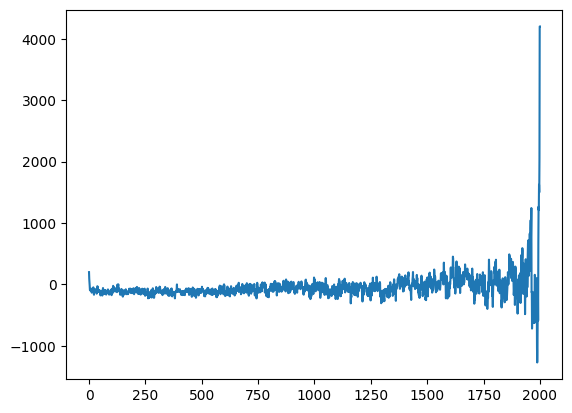

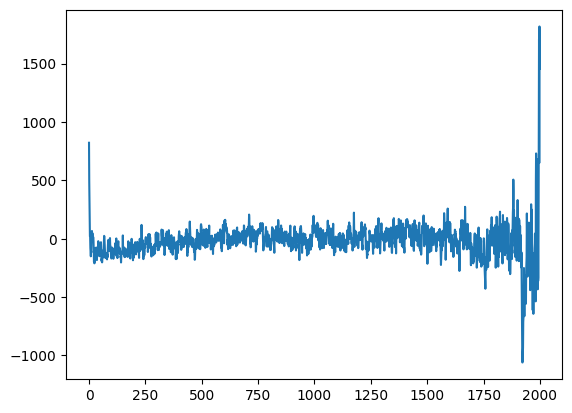

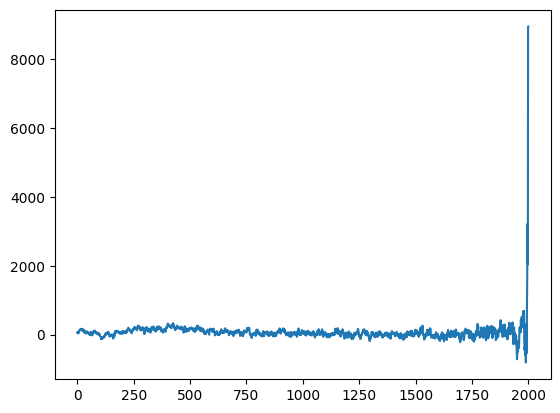

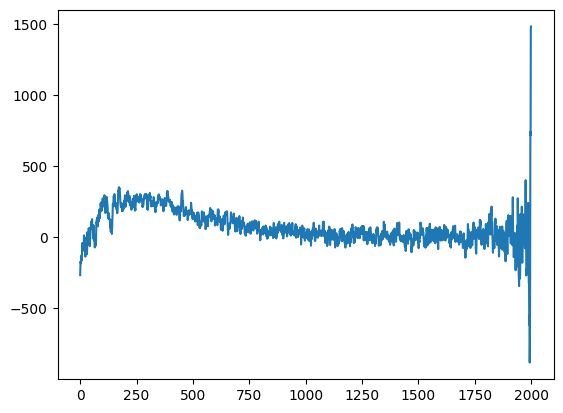

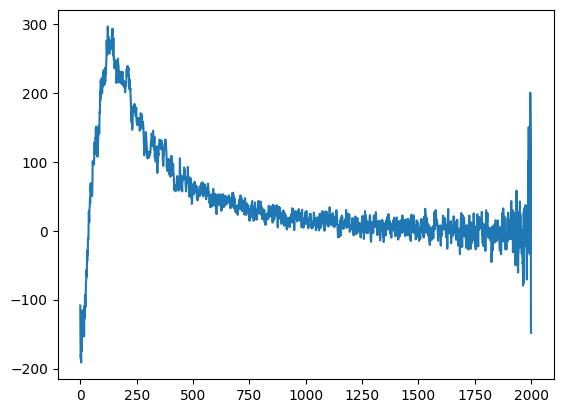

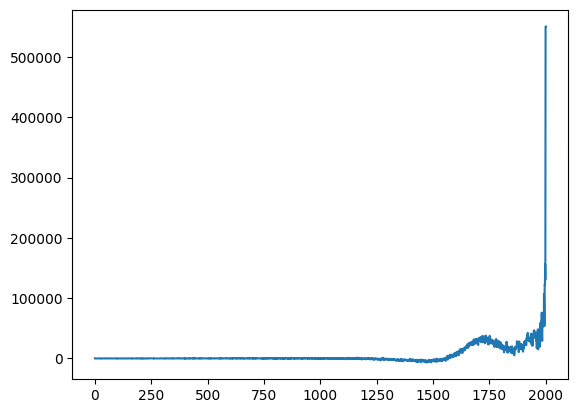

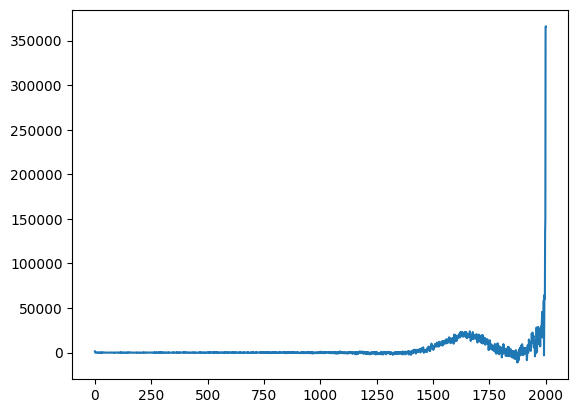

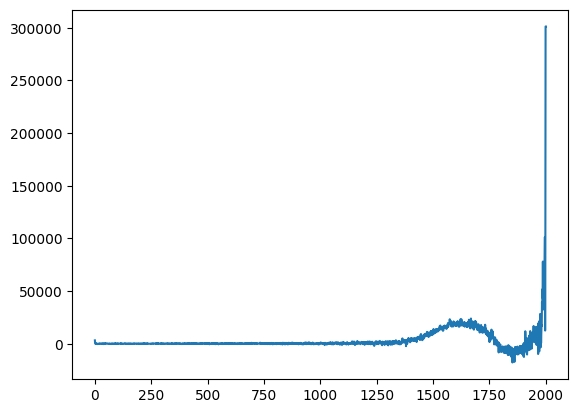

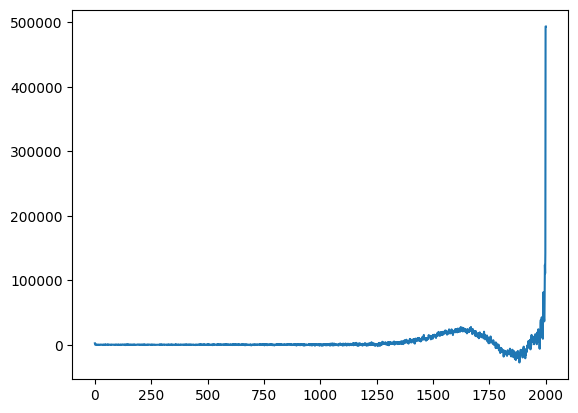

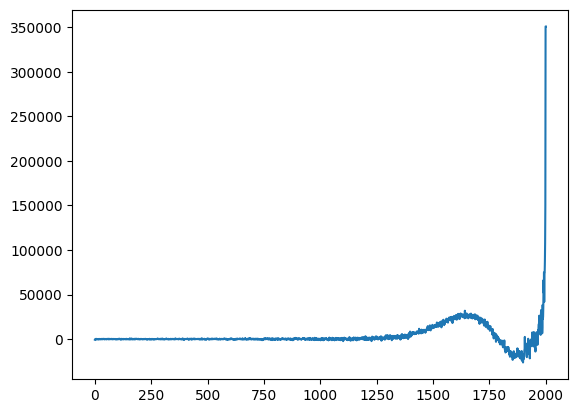

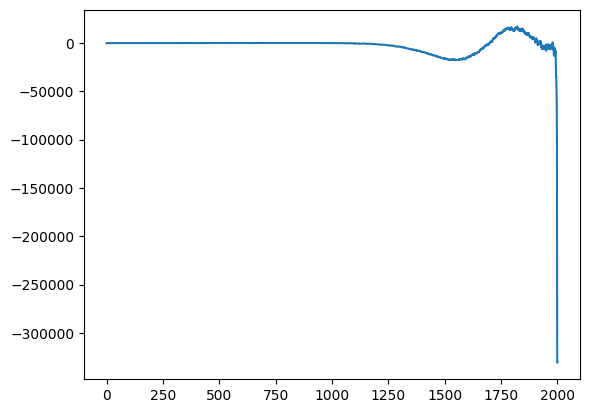

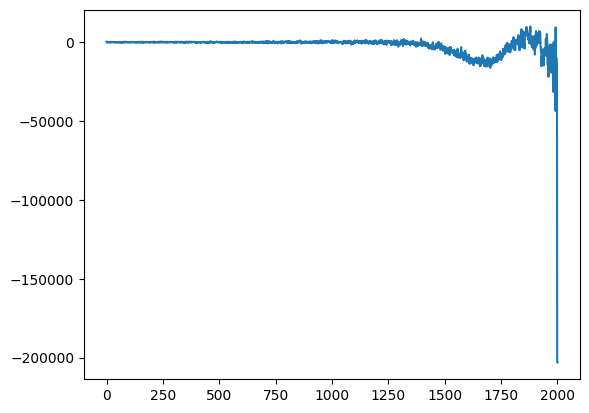

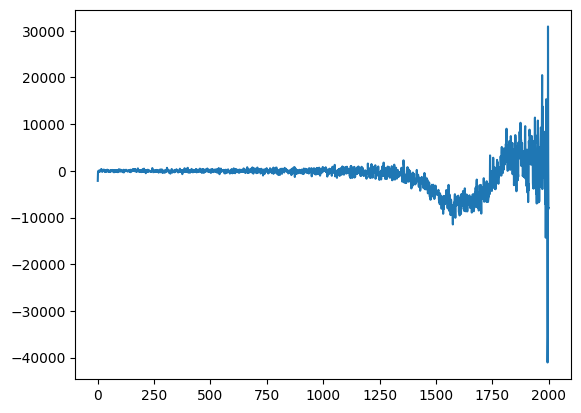

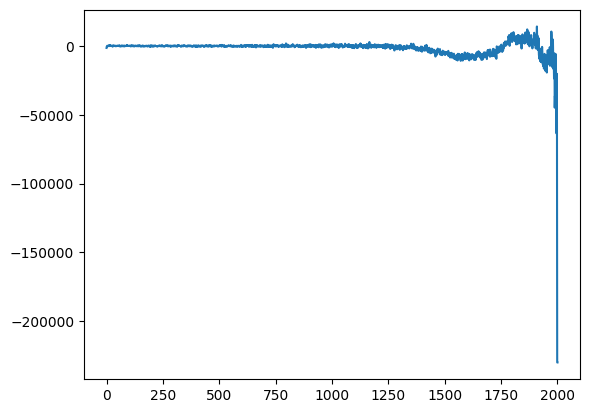

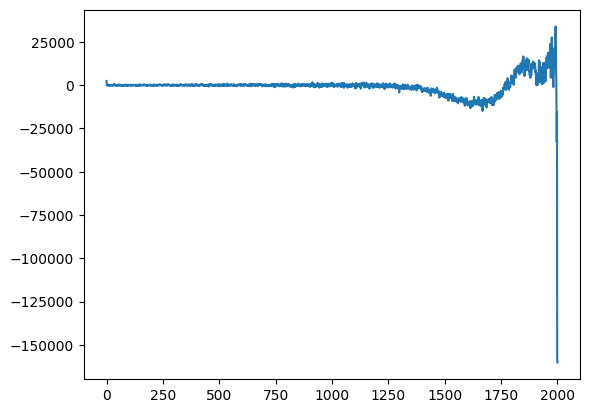

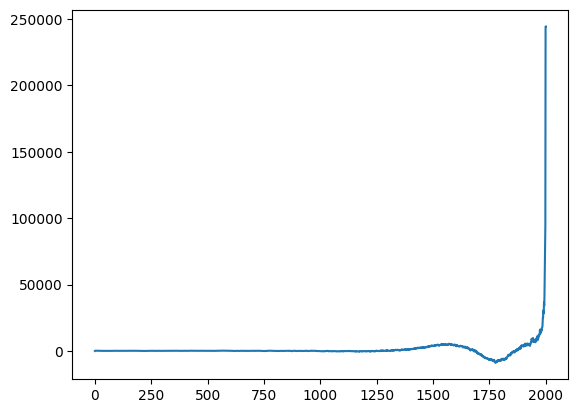

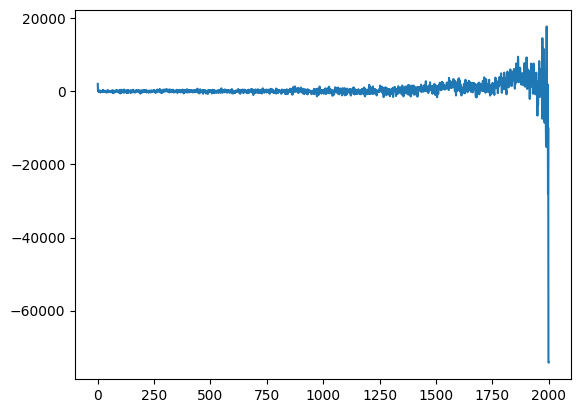

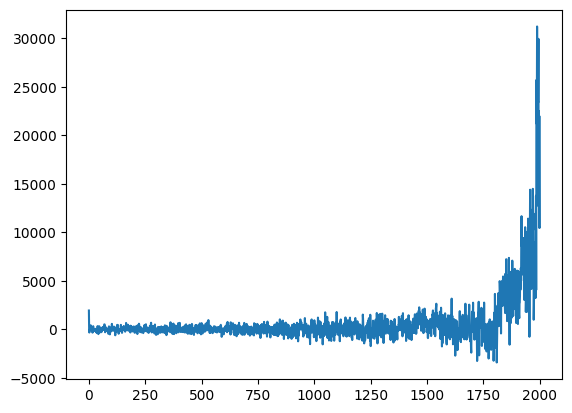

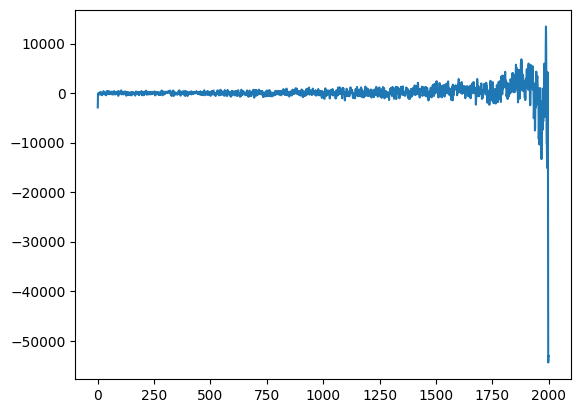

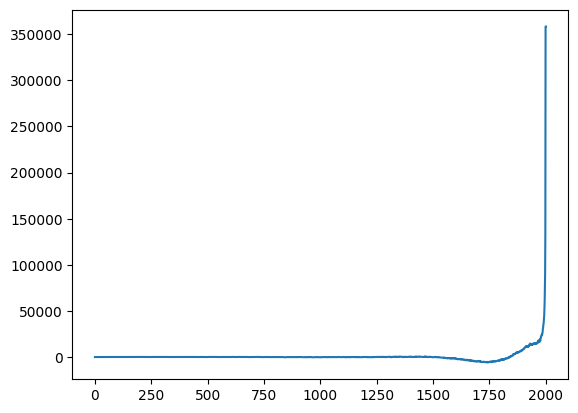

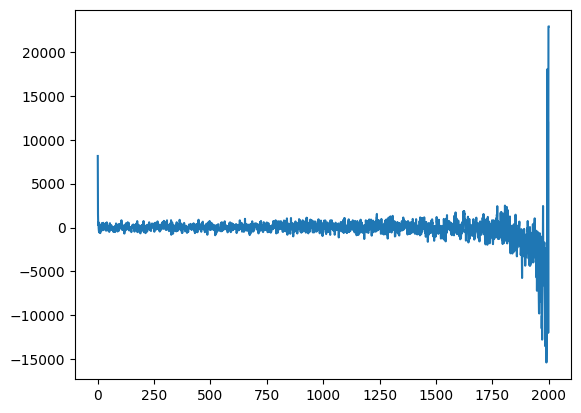

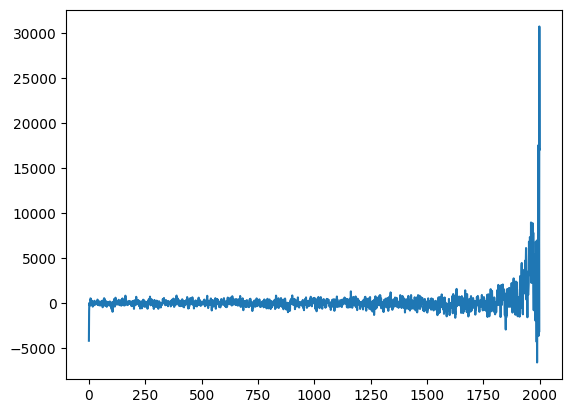

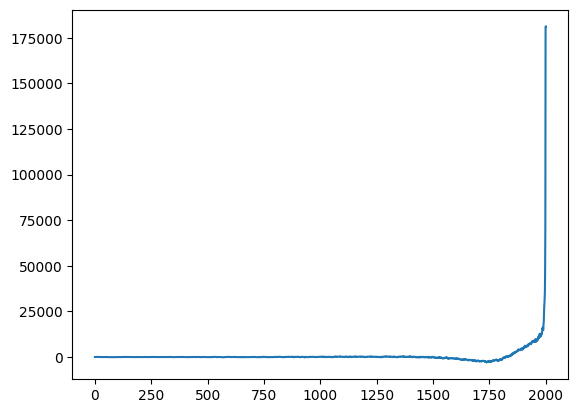

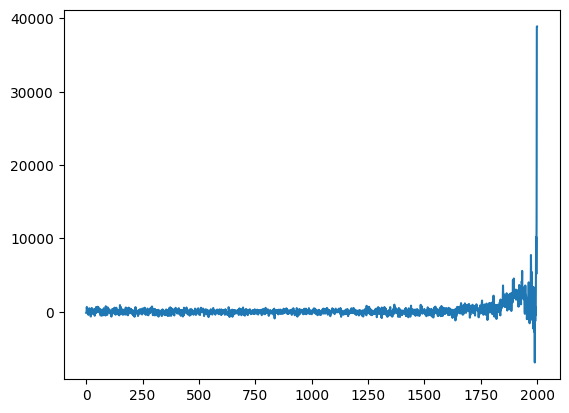

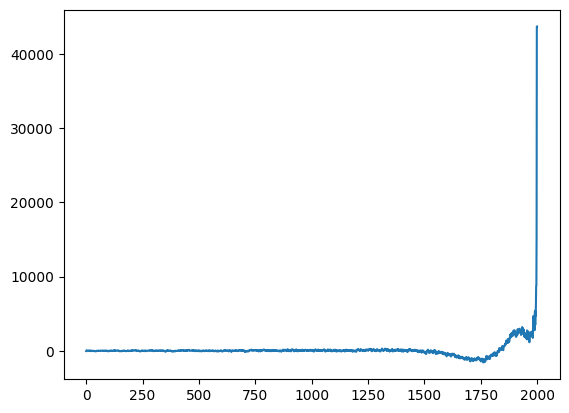

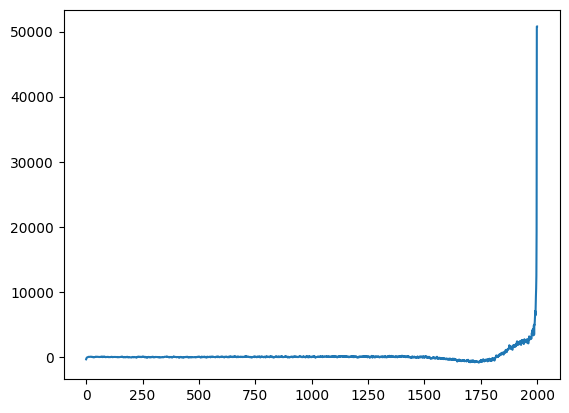

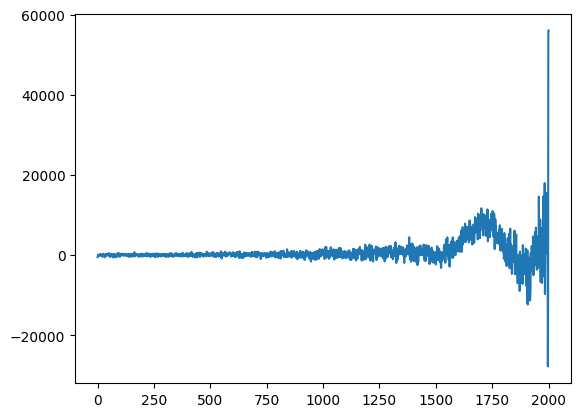

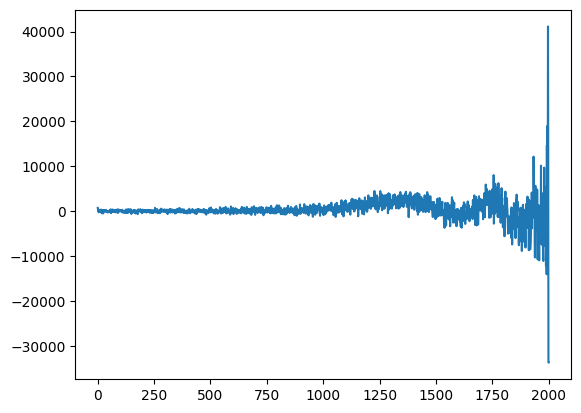

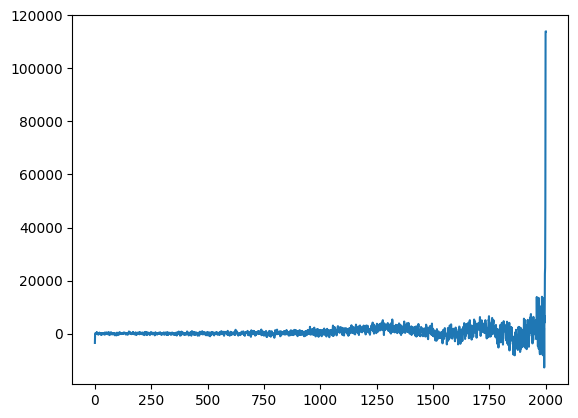

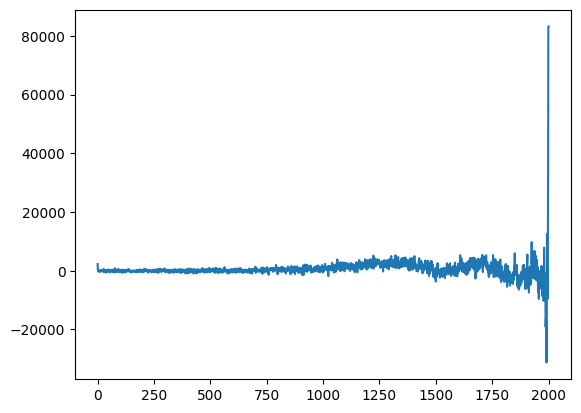

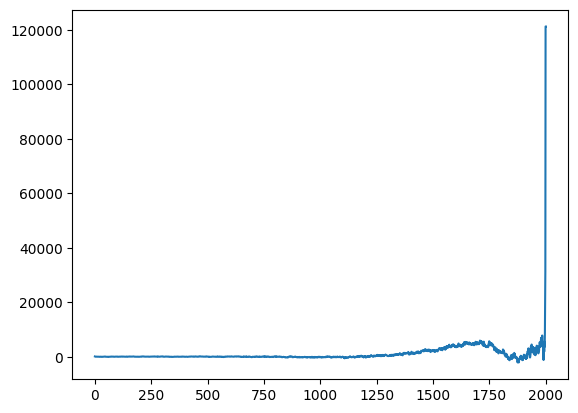

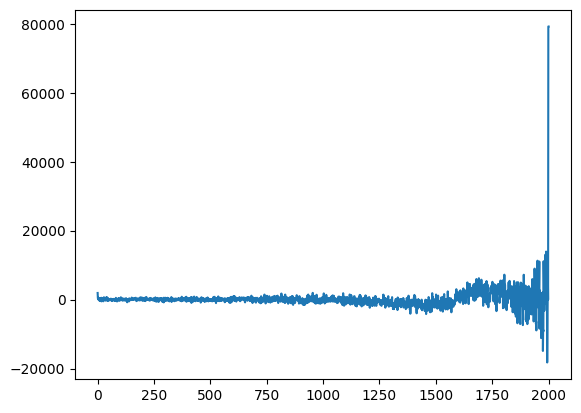

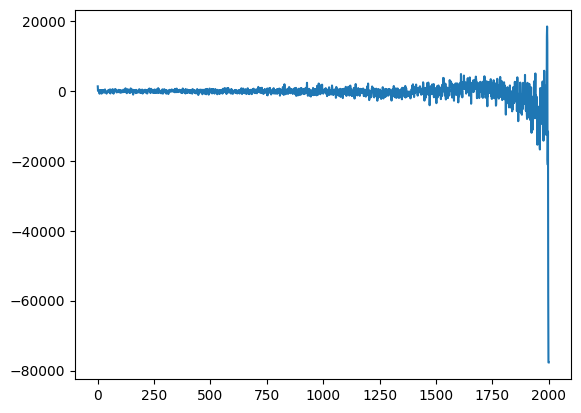

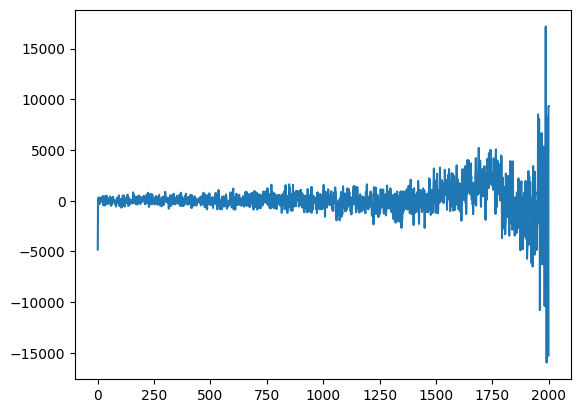

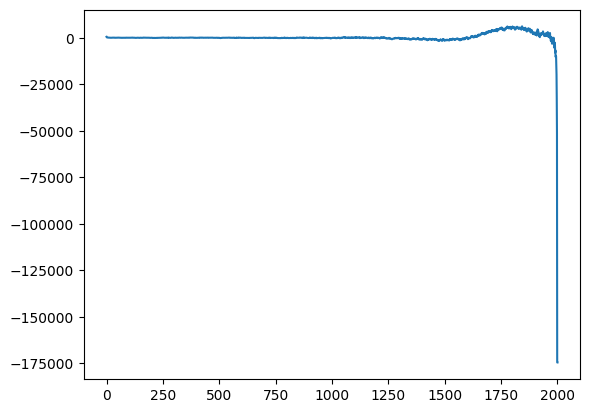

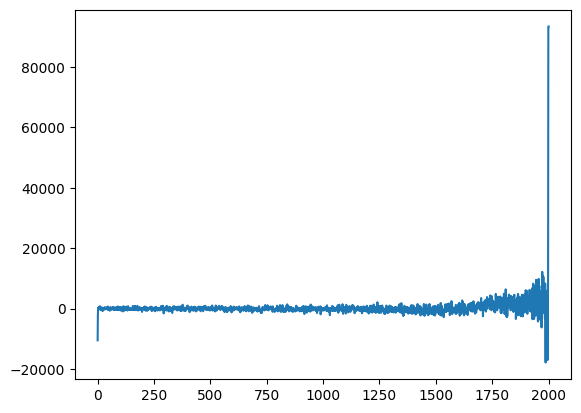

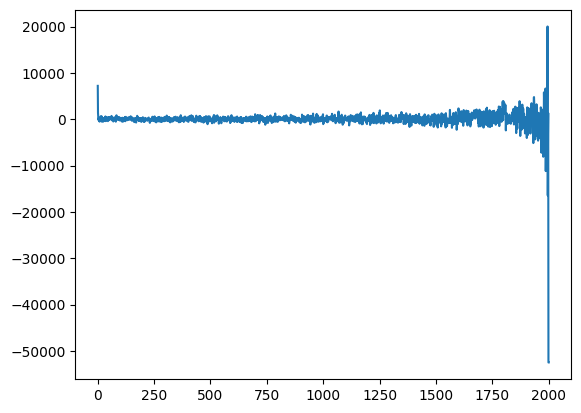

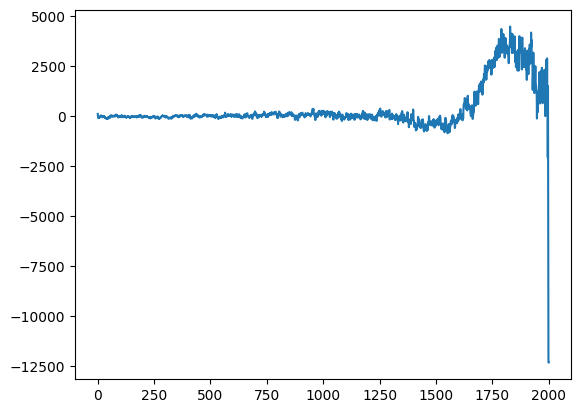

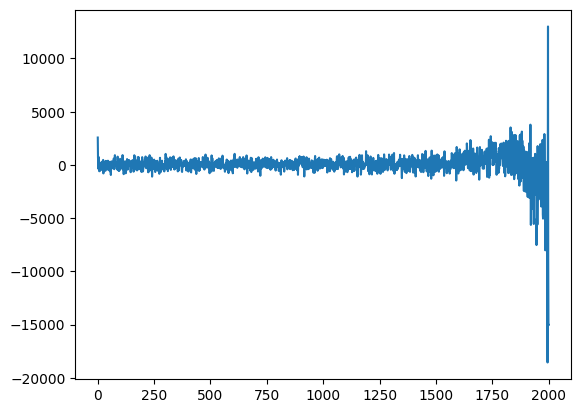

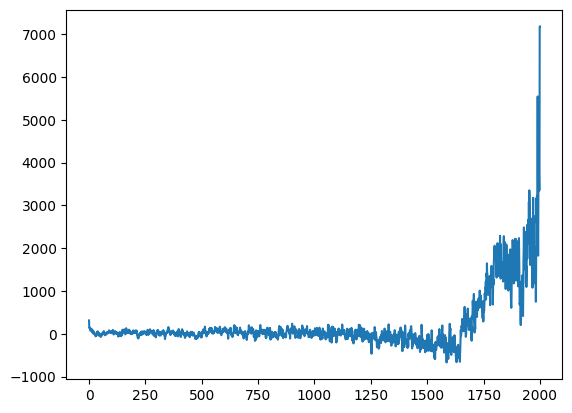

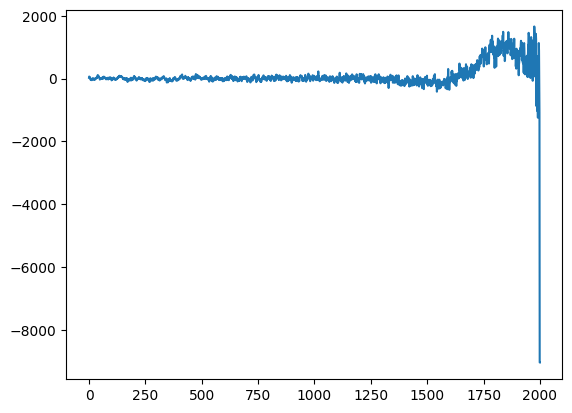

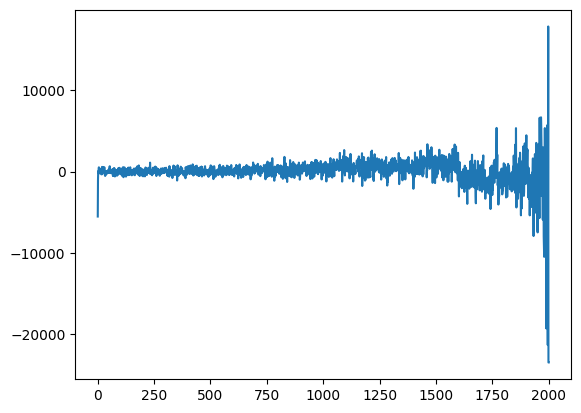

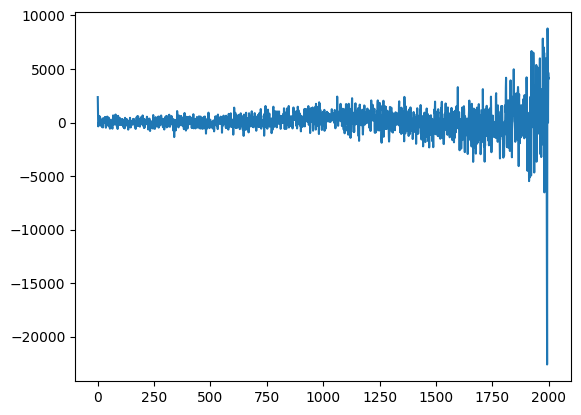

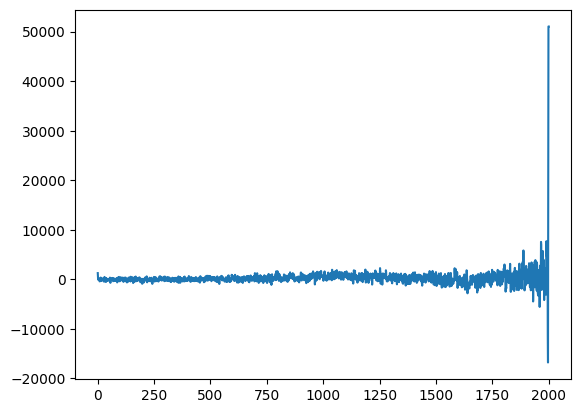

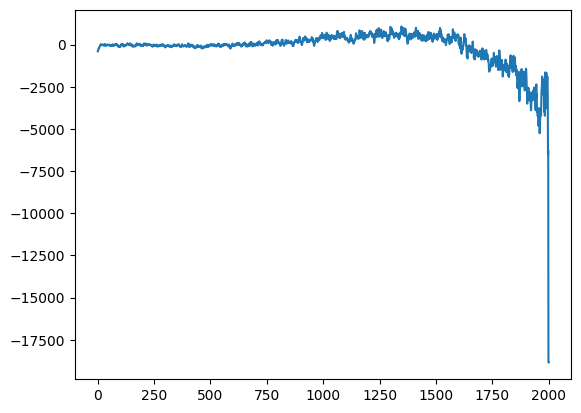

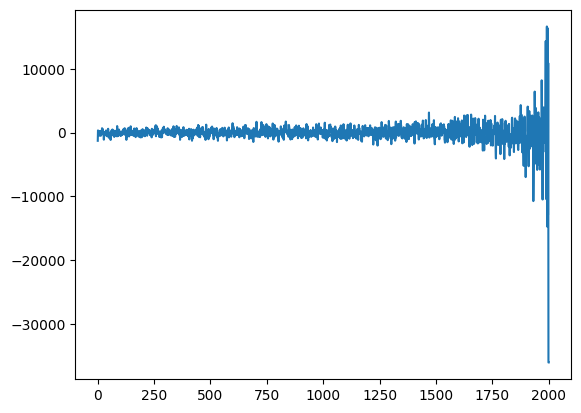

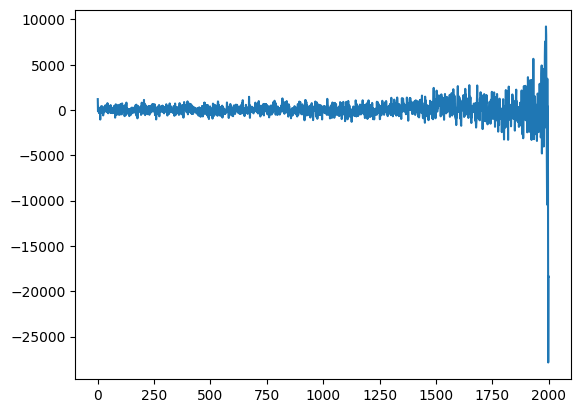

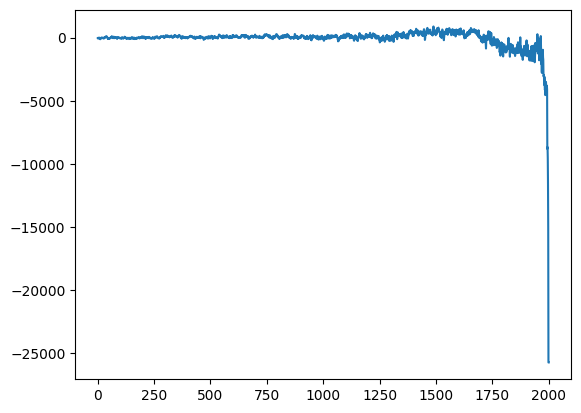

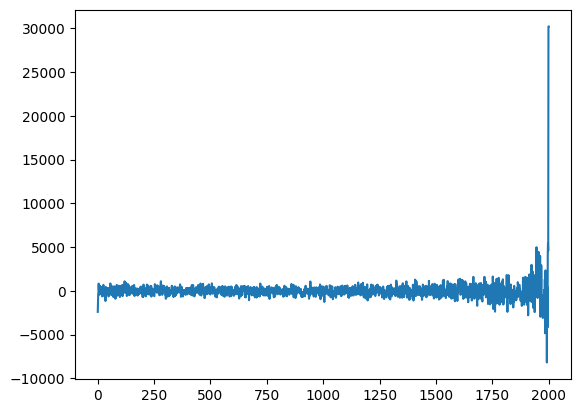

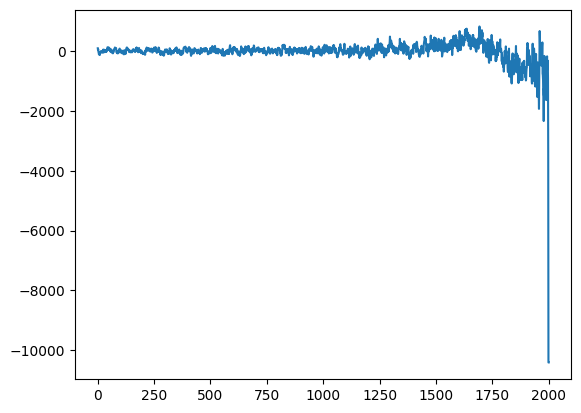

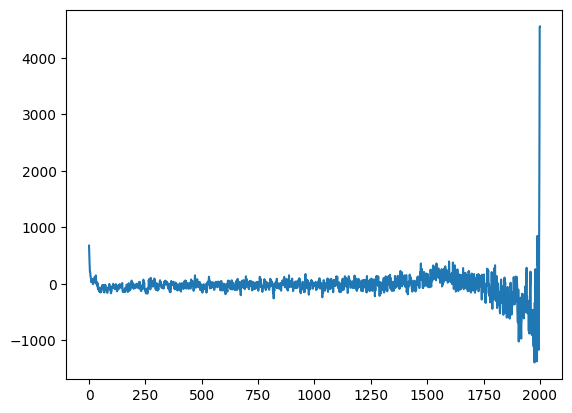

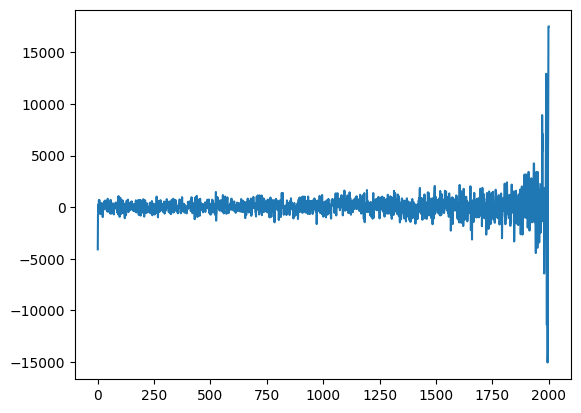

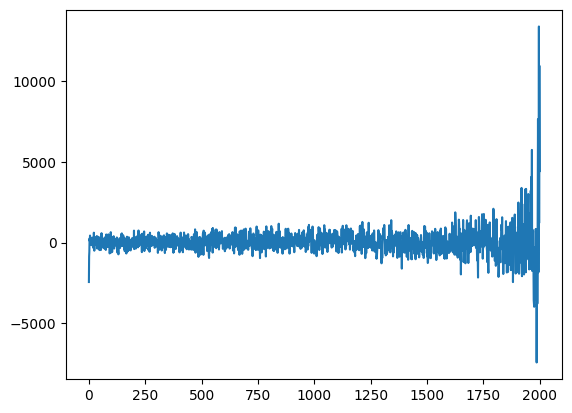

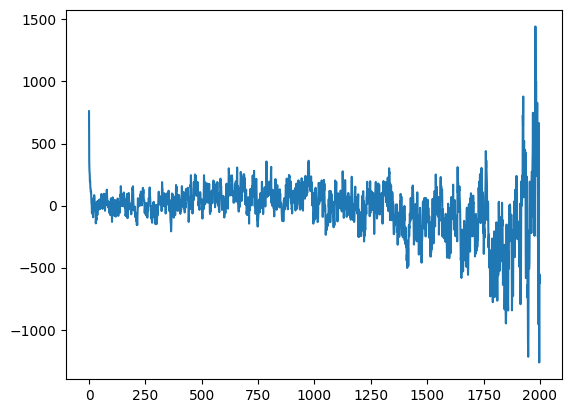

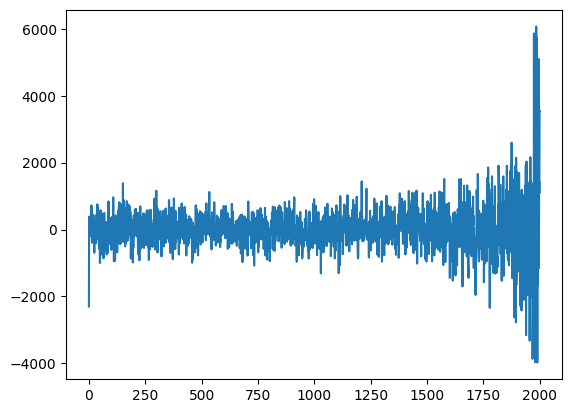

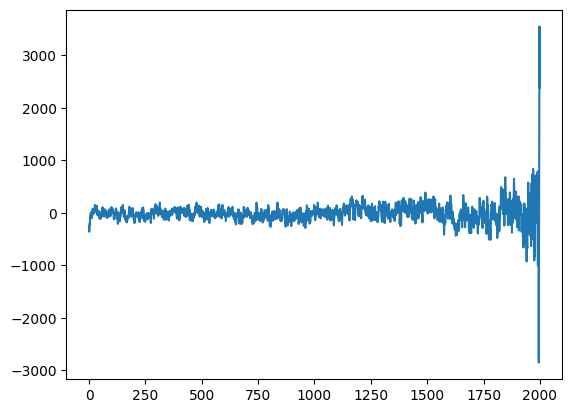

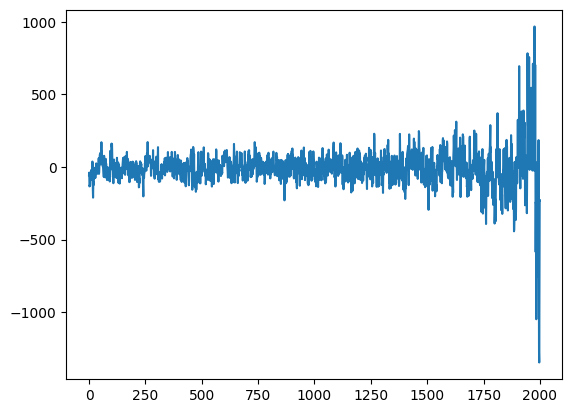

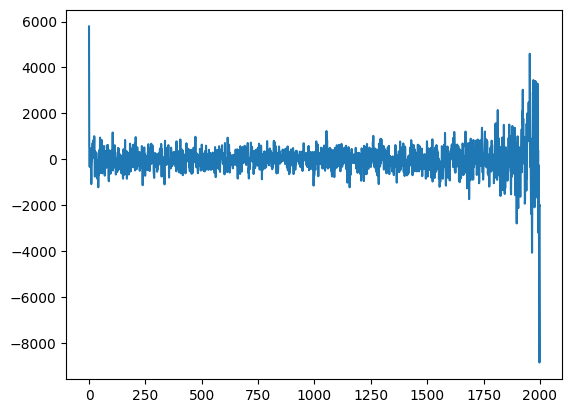

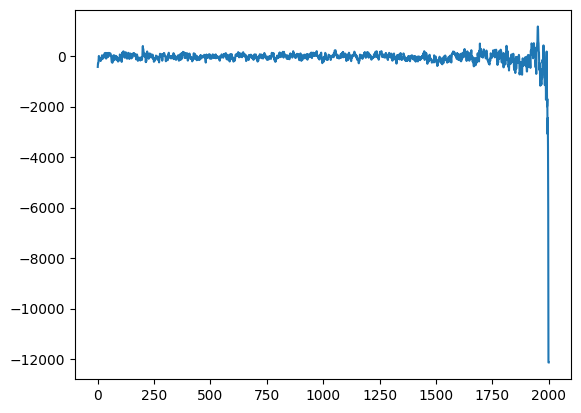

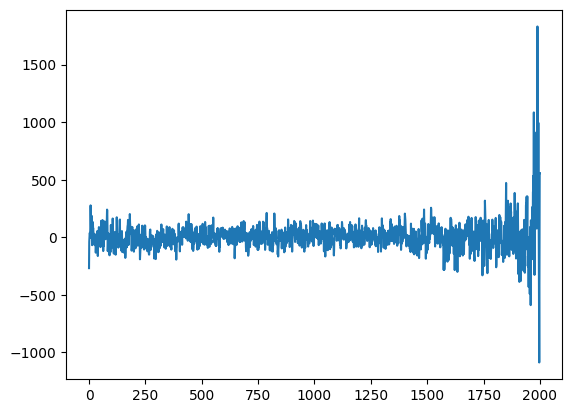

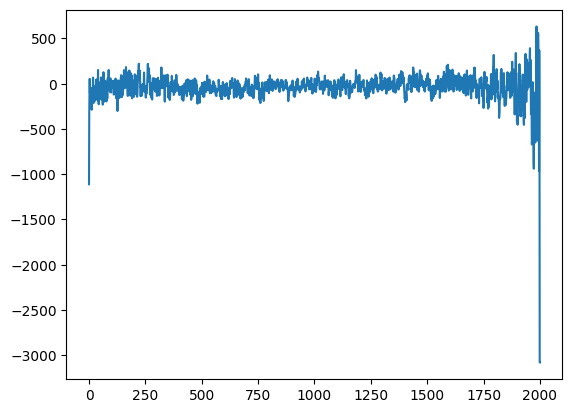

In [9]:
for key, exp in experiments.items():
    res = results[key]
    print(f"=== Experiment: {key} ===")
    
    theta_t = res["theta_t"].cpu() 
    print(theta_t.shape) 
    

    for i in range(0,theta_t.shape[1]): 
        plt.plot(theta_t[:,i]) 
        plt.show() 
        

## Moment matching diagnostics

CoshGt ψ


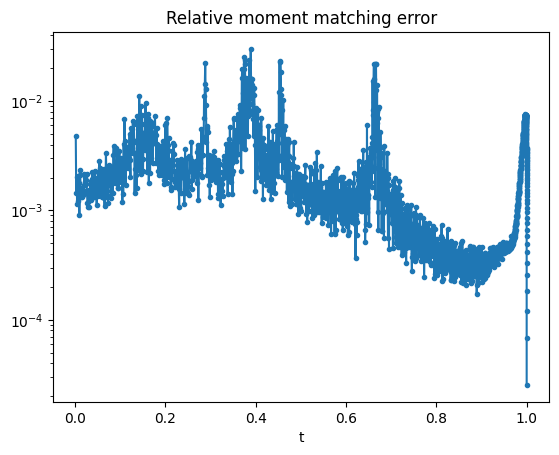

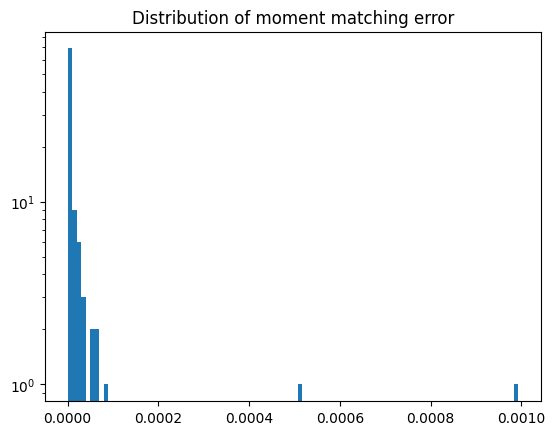

<Figure size 640x480 with 0 Axes>

In [10]:
threshold = 1e-8

for key, exp in experiments.items():
    res = results[key]
    print(exp['label'])
    if res.get('barphi_e') is None or res.get('barphi_p') is None:
        print('Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.')
    else:
        plot_moment_matching(res['barphi_e'], res['barphi_p'], res['t'], threshold)
        plt.suptitle(exp['label'])
        plt.show()


## Visual comparison of samples

torch.Size([10000, 1, 128])
CoshGt ψ


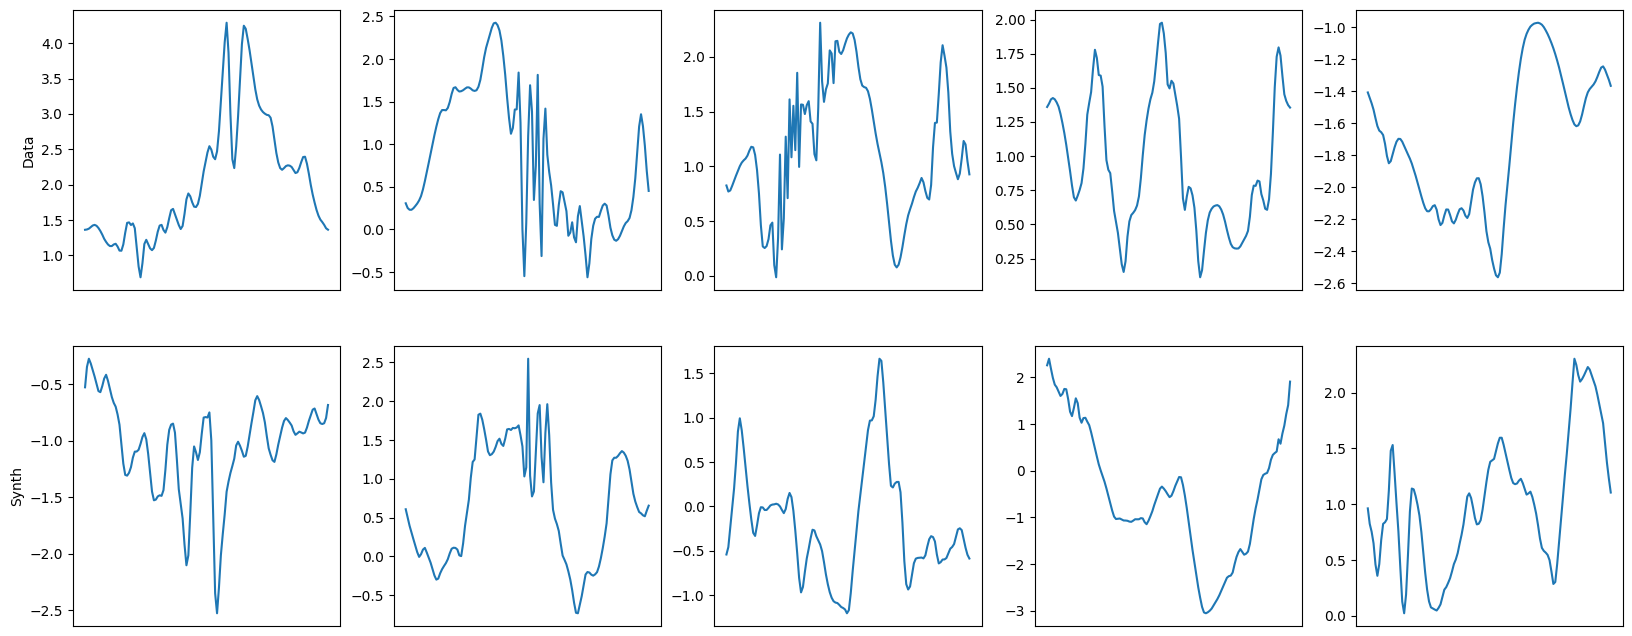

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


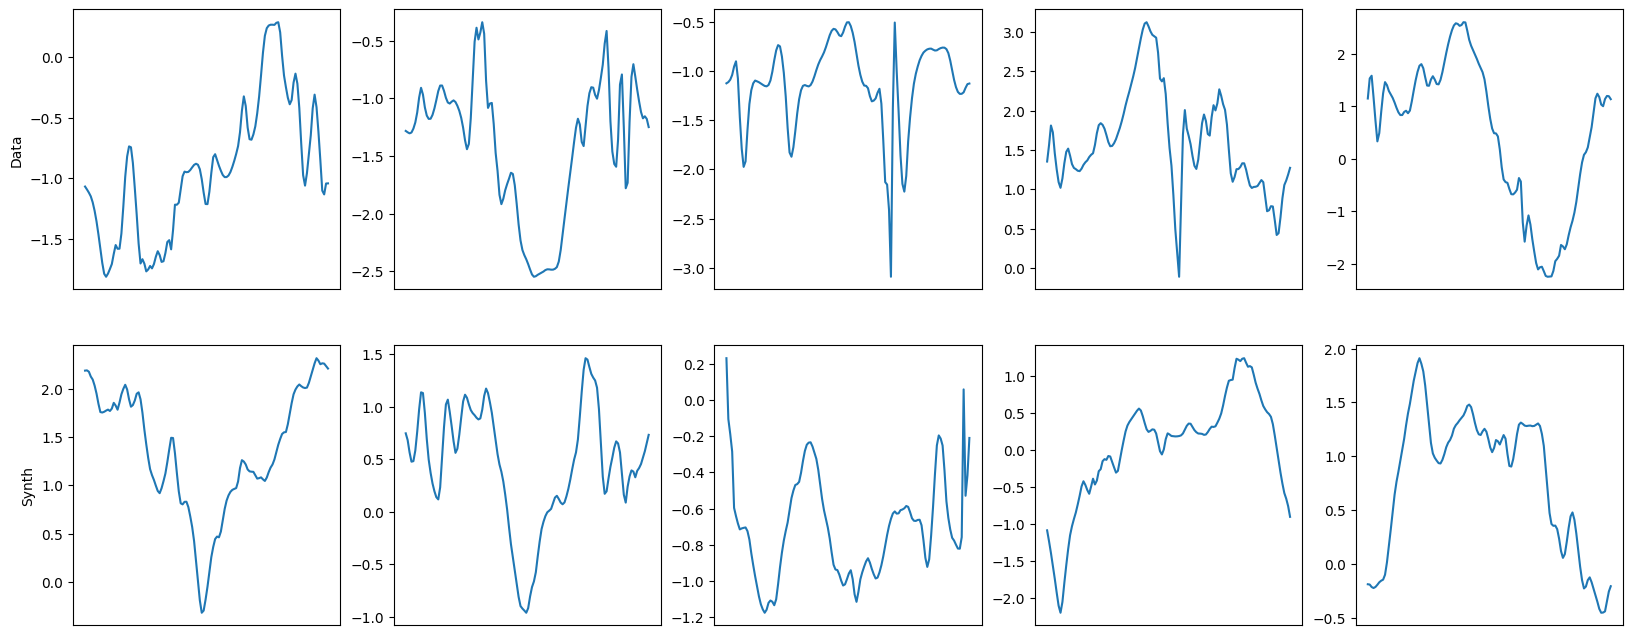

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


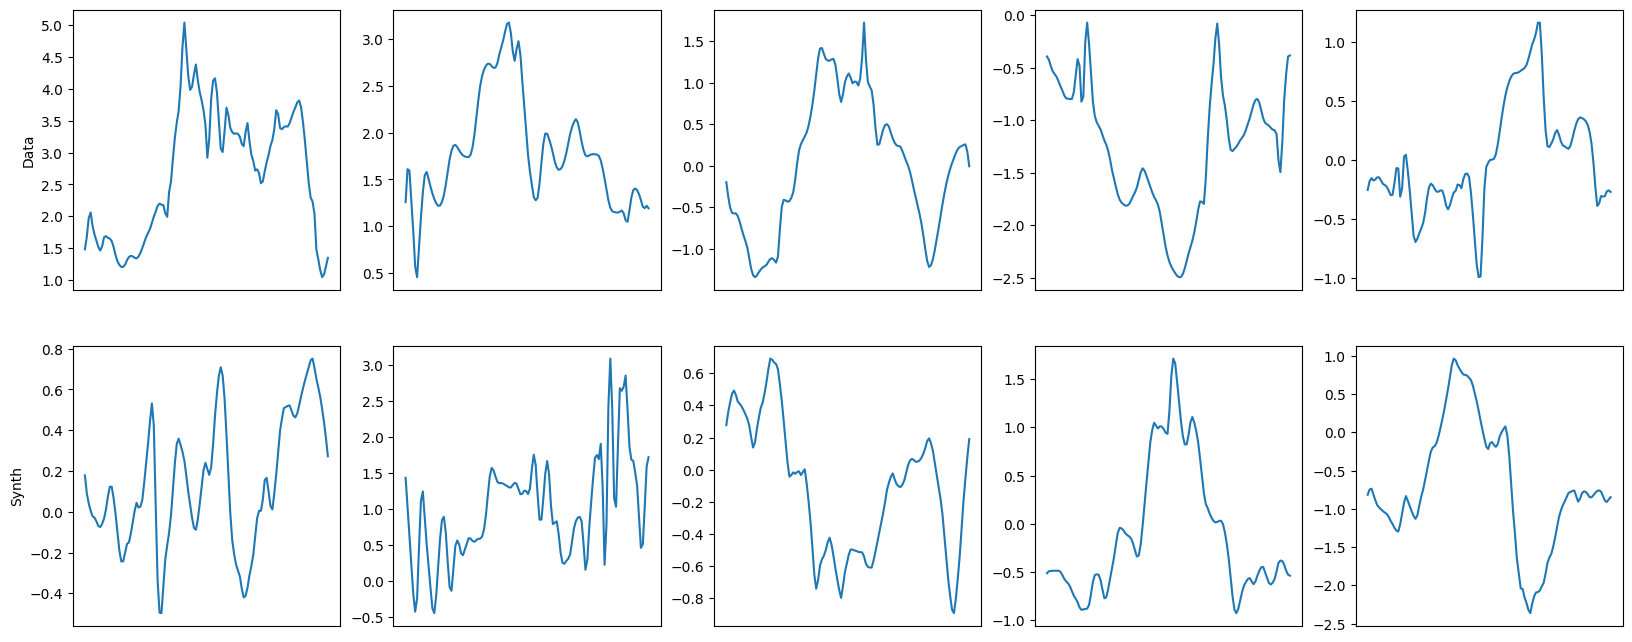

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


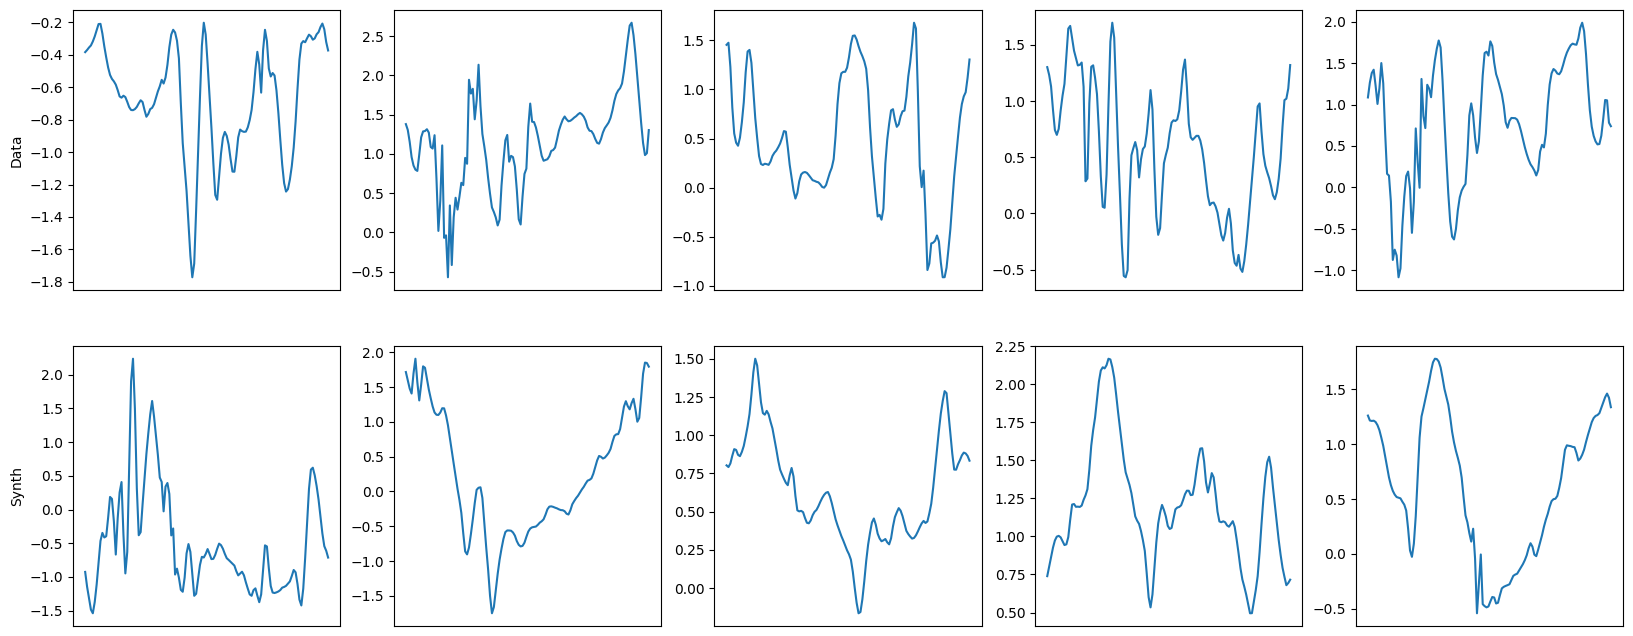

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


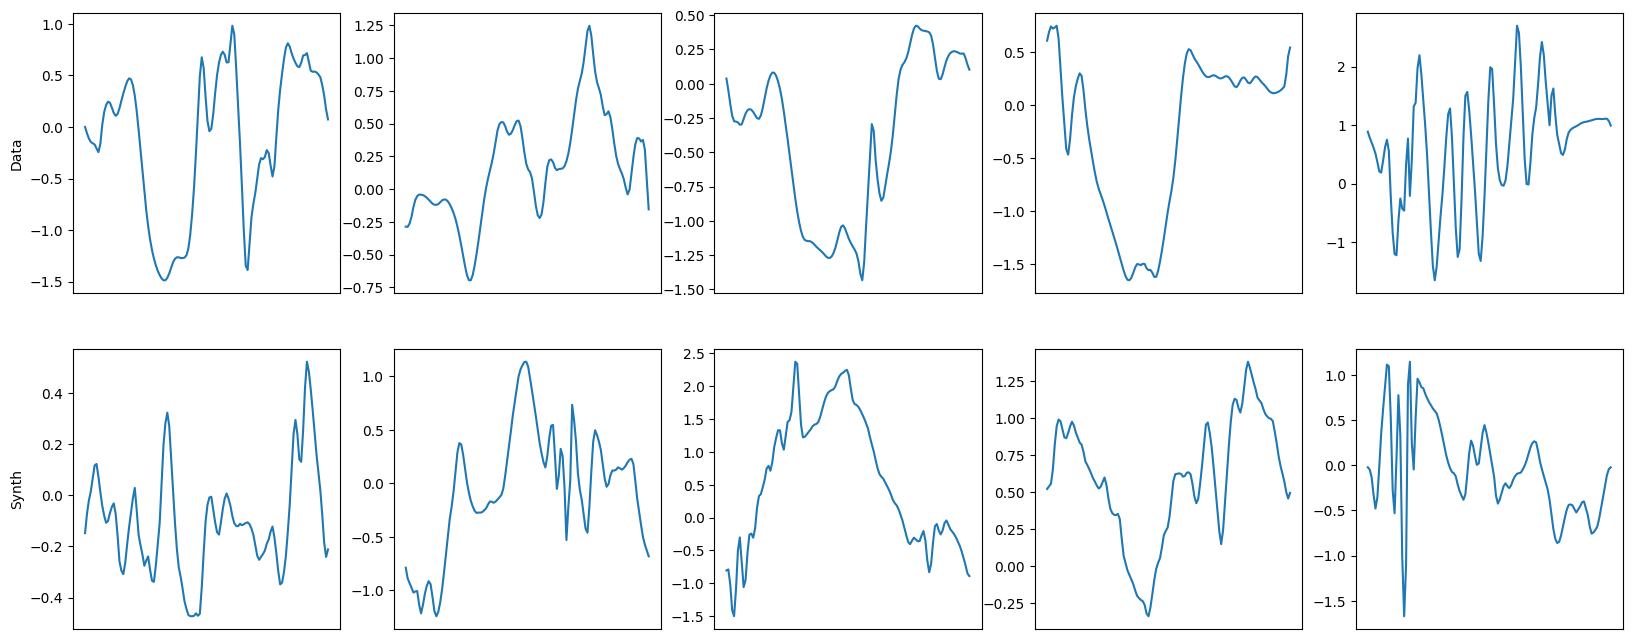

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


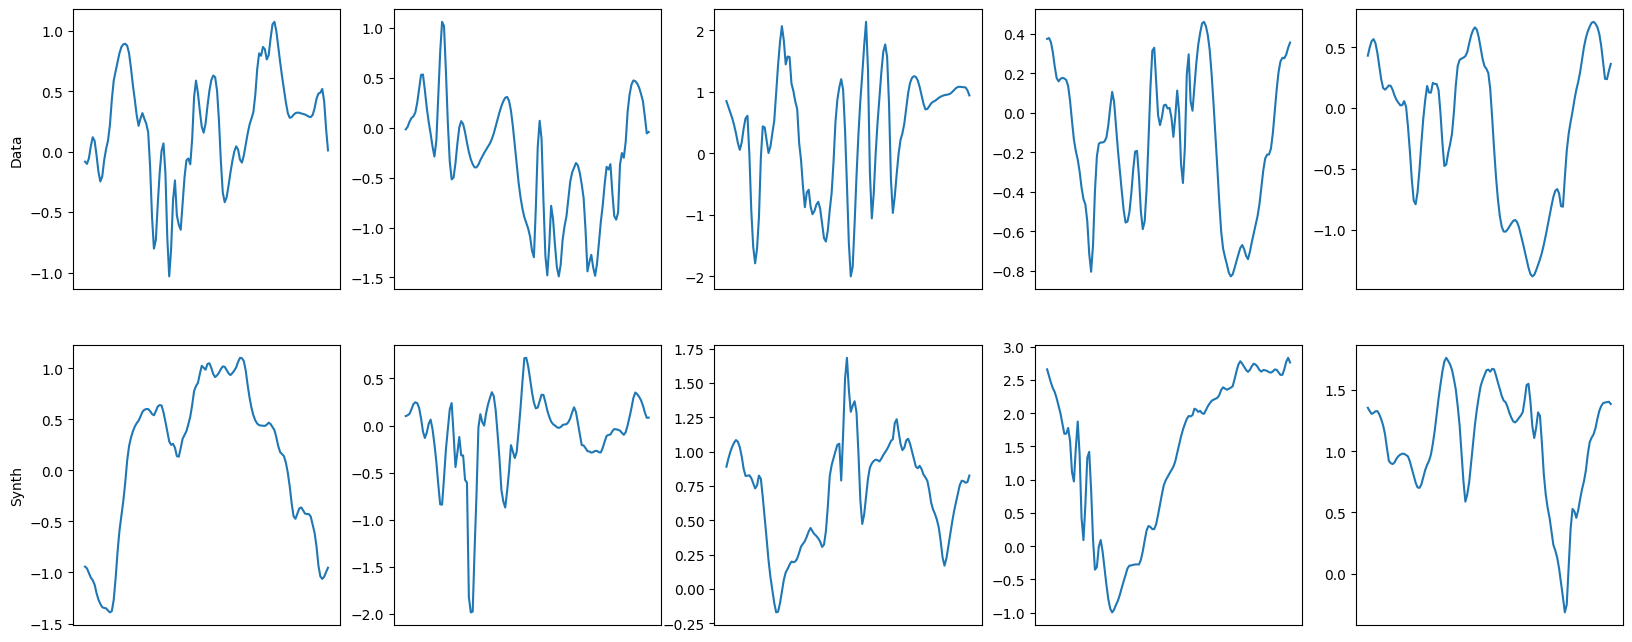

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


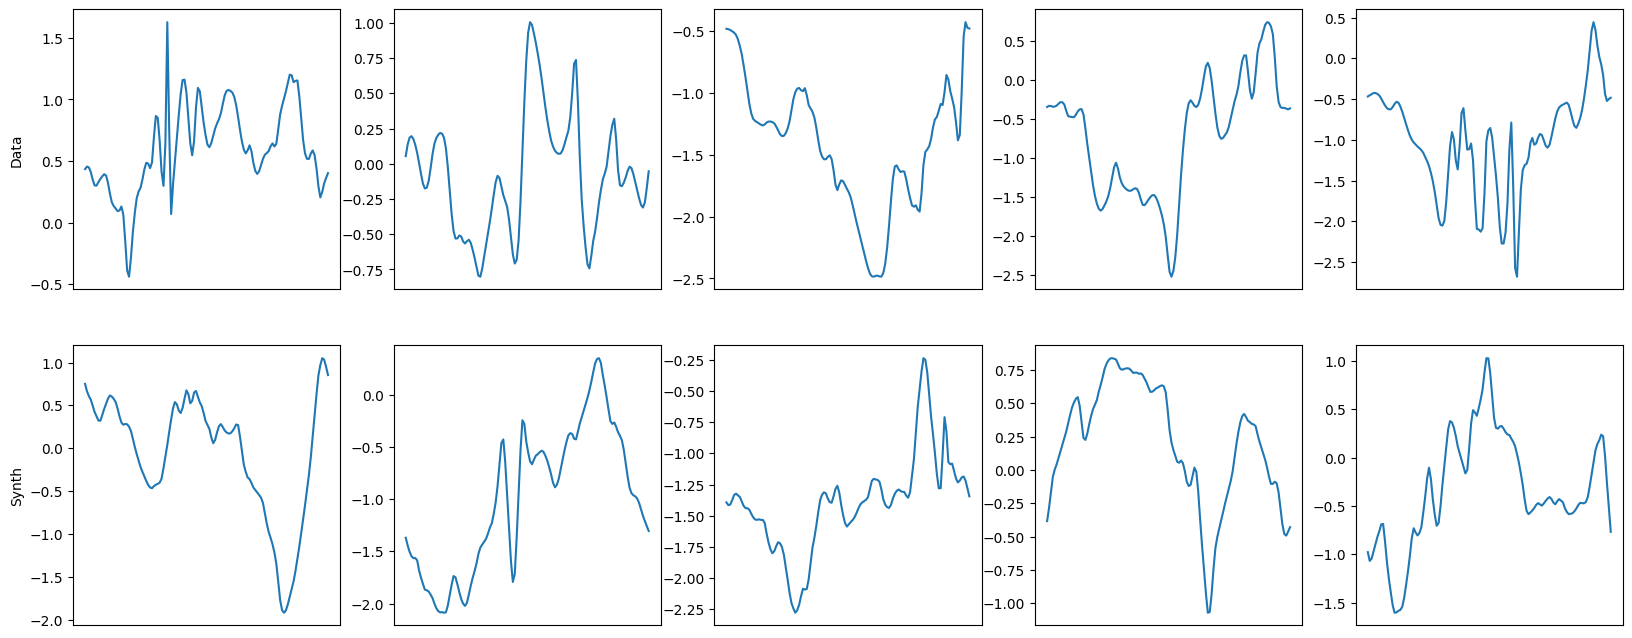

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


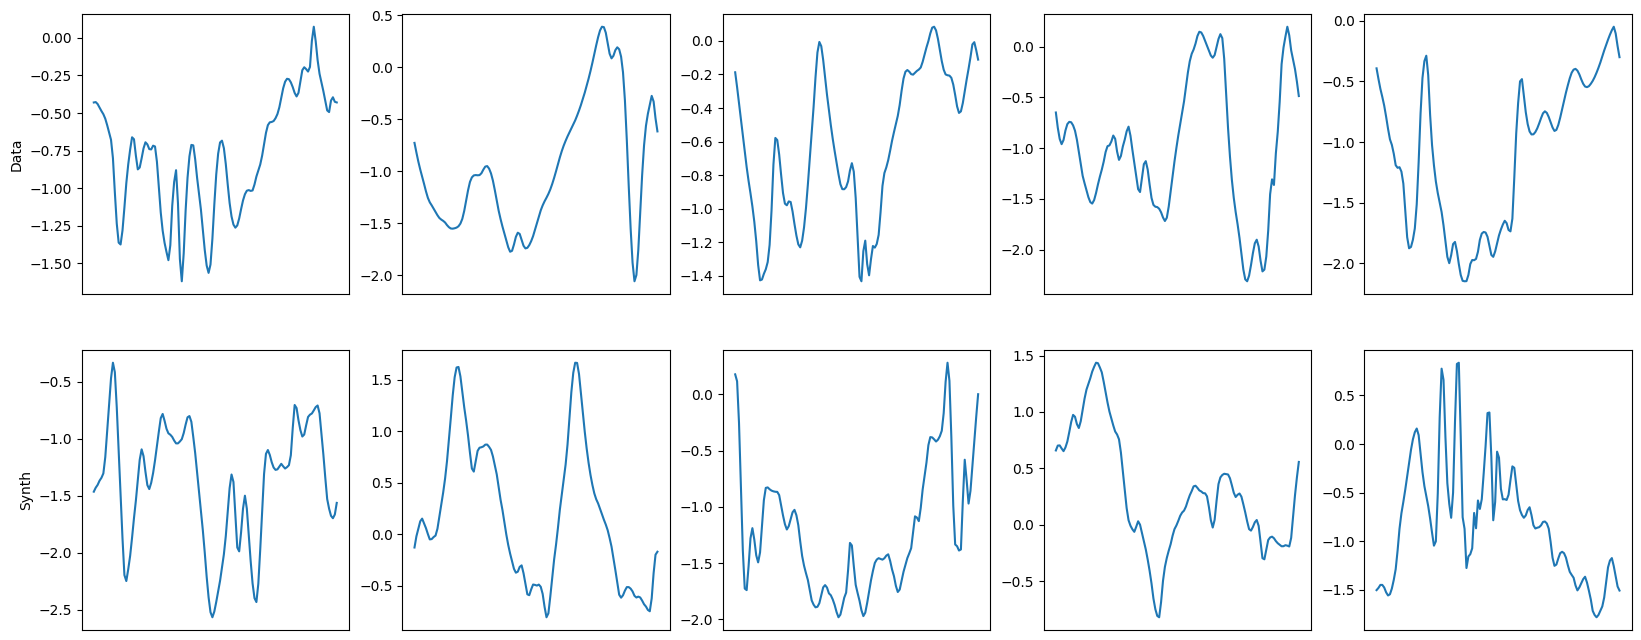

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


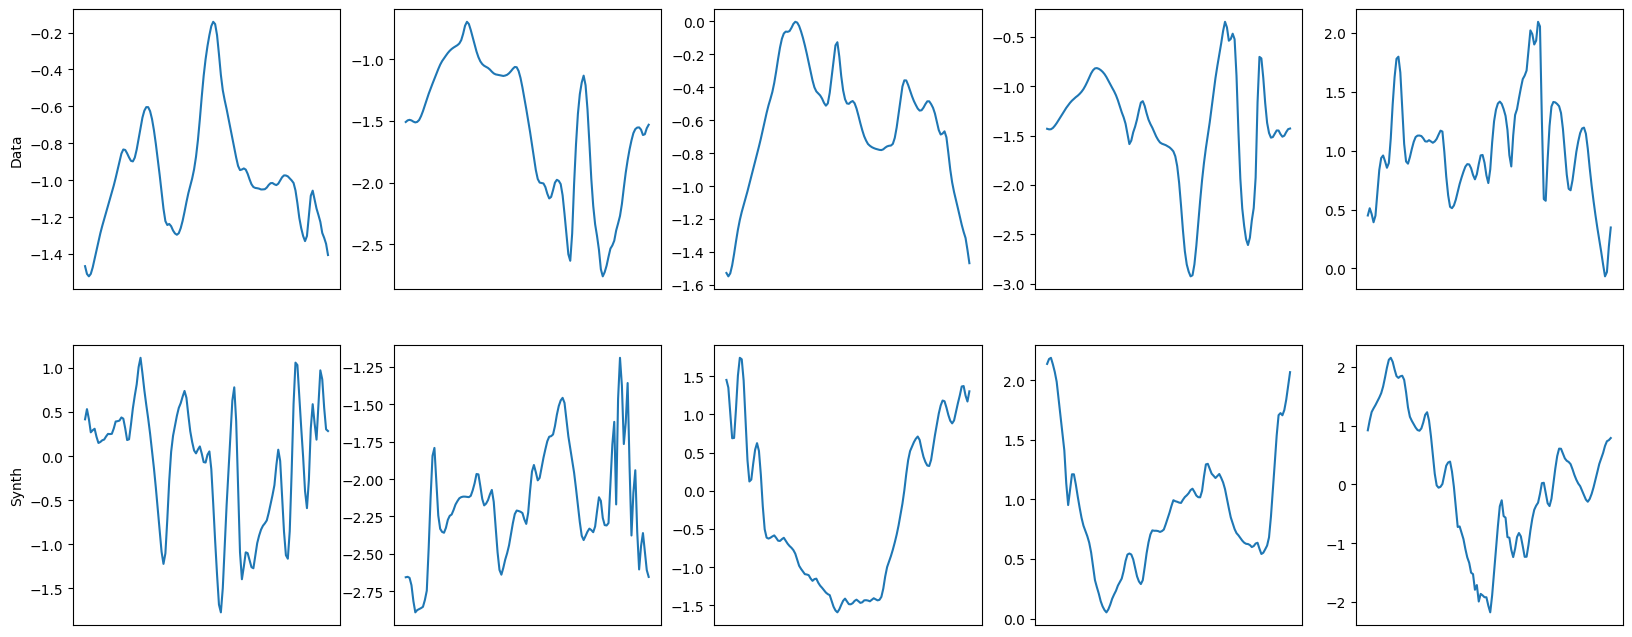

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


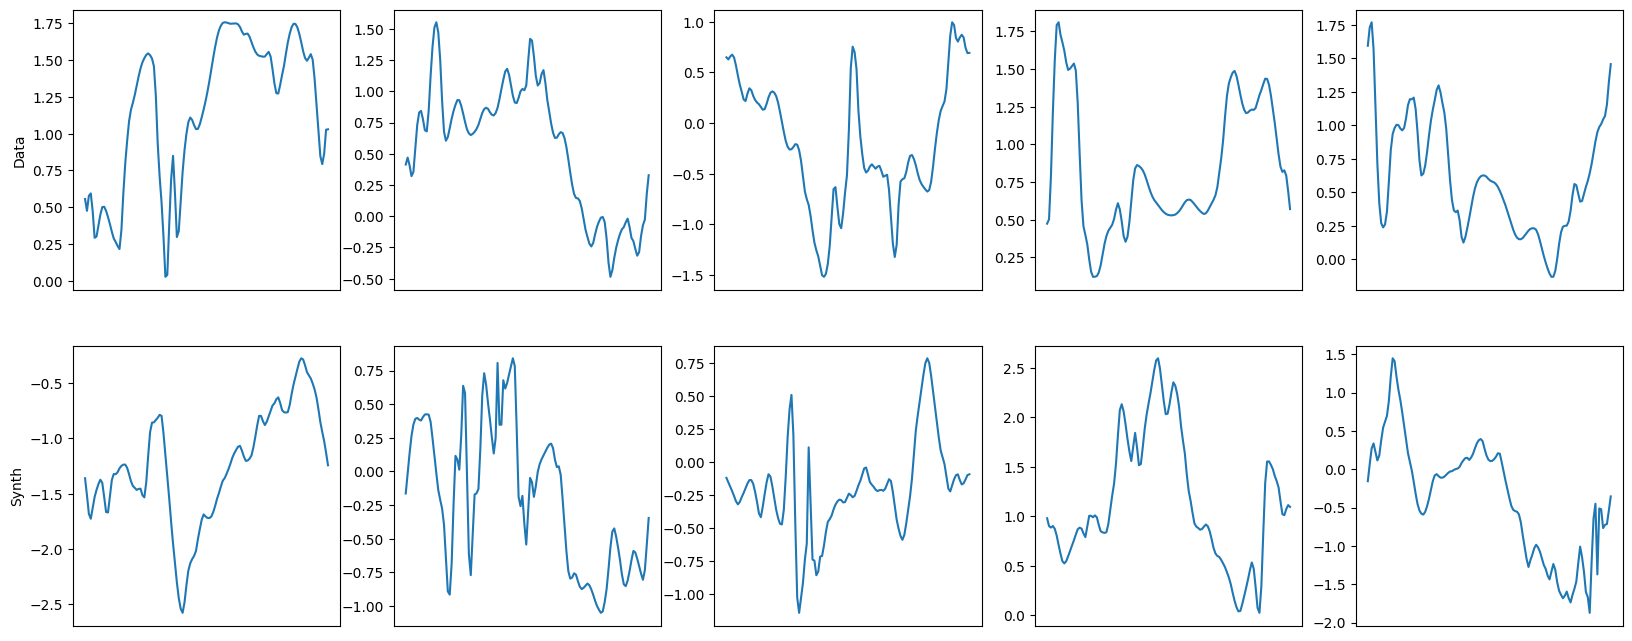

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


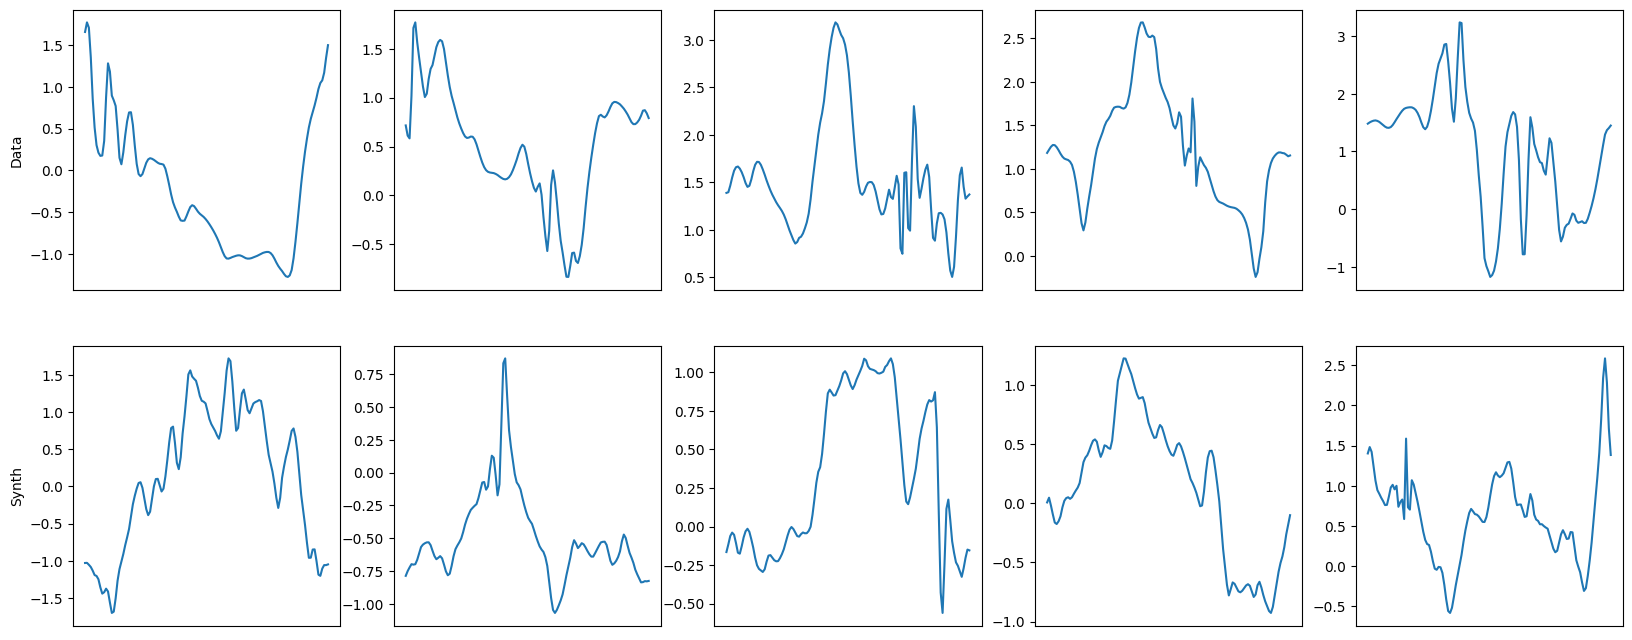

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


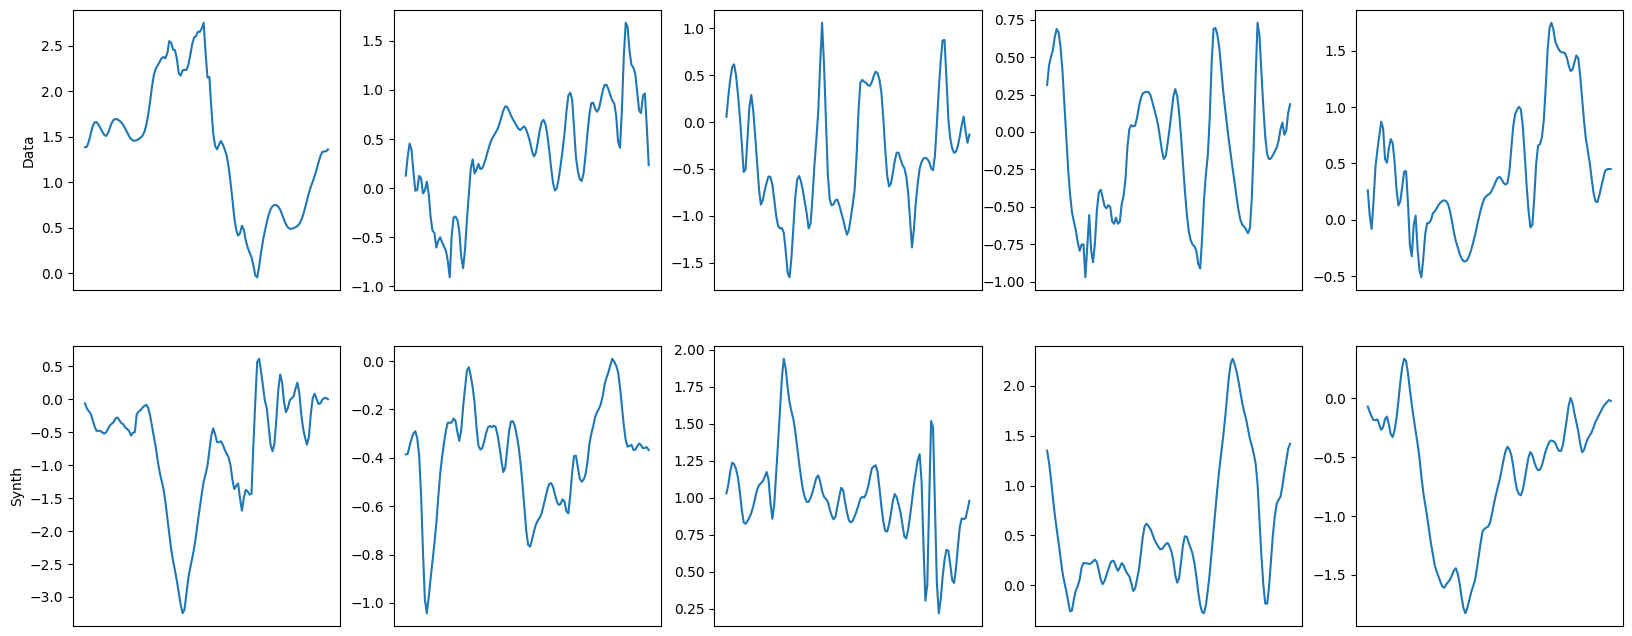

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


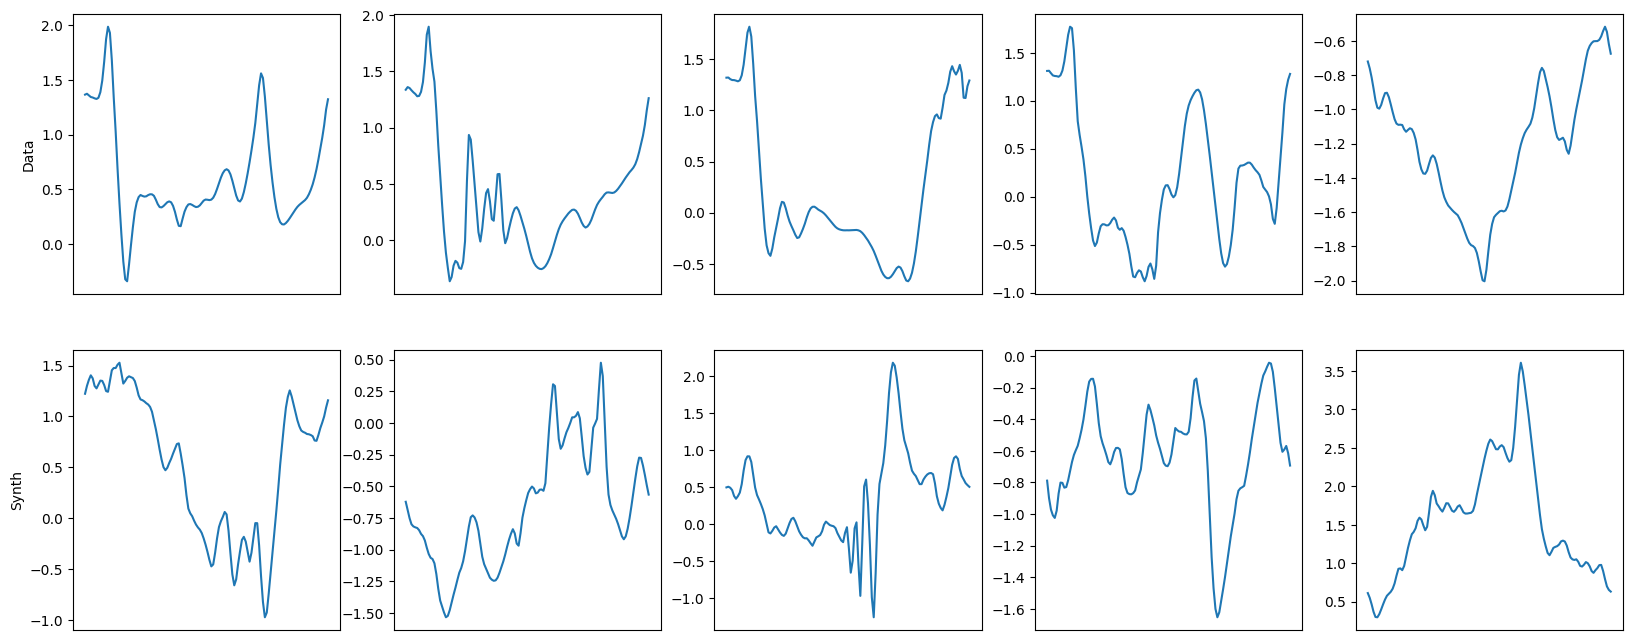

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


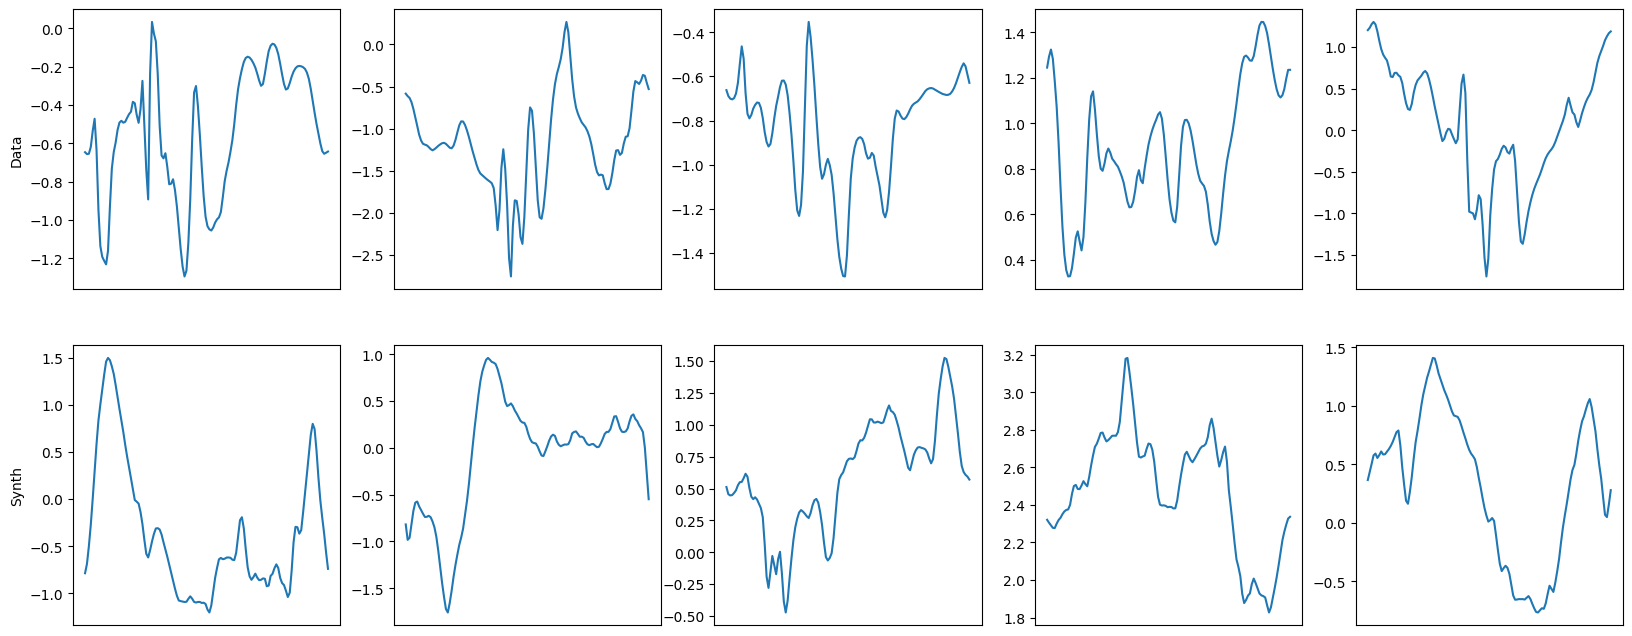

<Figure size 640x480 with 0 Axes>

torch.Size([10000, 1, 128])
CoshGt ψ


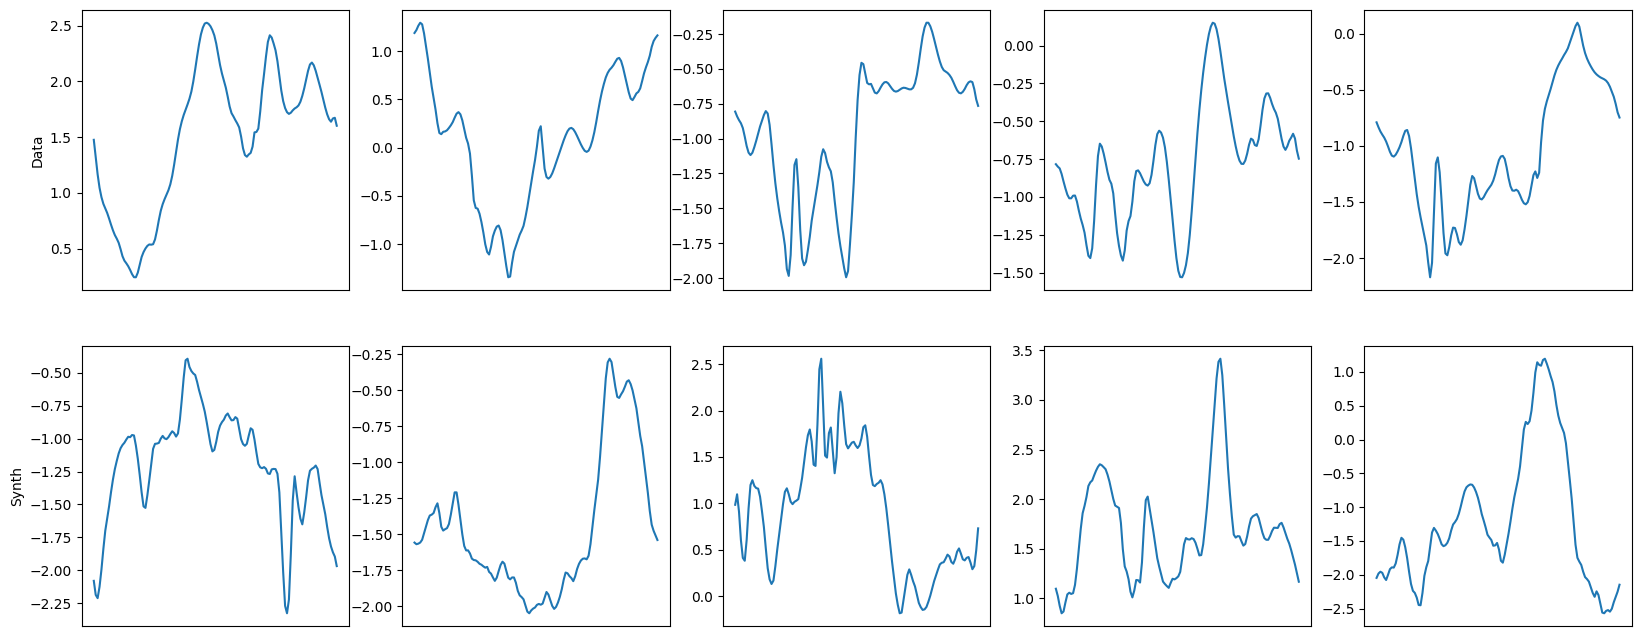

<Figure size 640x480 with 0 Axes>

In [11]:
for i in range(0,15): 
    for key, exp in experiments.items():
        print(results[key]['xt'].shape) 
        print(exp['label'])
        Compare_time_series_row(x1[i*5:i*5+5,:,:], results[key]['xt'][i*5:i*5+5,:,:],5)
        plt.suptitle(exp['label'])
        plt.show()


## Existing project diagnostics, side by side by model

Spectrum
CoshGt ψ


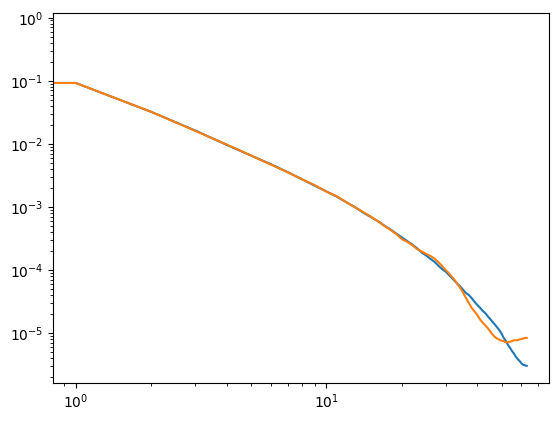

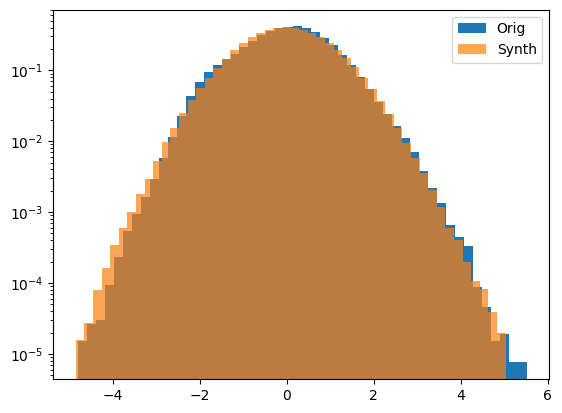

<Figure size 640x480 with 0 Axes>

Histogram
CoshGt ψ


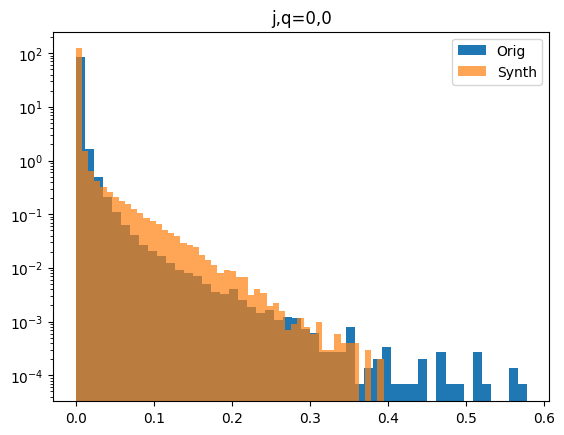

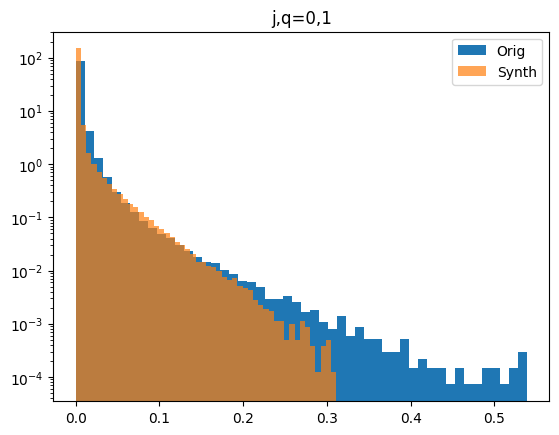

In [ ]:
def run_project_diagnostics(x_ref, results, experiments):
    """
    Uses the existing project plotting utilities. These functions usually create
    their own figures, so we call each diagnostic once per model and add titles.
    """
    diagnostic_functions = [
        ('Spectrum', spec_plot),
        ('Histogram', hist_plot),
        ('Structure functions', structure_plot),
    ]

    for diag_name, diag_fun in diagnostic_functions:
        print('' + '=' * 80)
        print(diag_name)
        print('=' * 80)
        for key, exp in experiments.items():
            print(exp['label'])
            diag_fun(x_ref, results[key]['xt'])
            plt.suptitle(f"{diag_name}: {exp['label']}")
            plt.show()

    print('' + '=' * 80)
    print('Cross statistics')
    print('=' * 80)
    for key, exp in experiments.items():
        print(exp['label'])
        cross_plot(x_ref, results[key]['xt'], pq=[(3, 1), (3, 3), (4, 4)])
        plt.suptitle(f"Cross statistics: {exp['label']}")
        plt.show()

run_project_diagnostics(x1, results, experiments)


## Quantitative comparison metrics

The following metrics are intentionally simple and independent from the plotting utilities:

- **Mean / std error:** relative mismatch of first two moments.
- **Spectrum relative MSE:** mismatch of the average Fourier power spectrum.
- **Histogram Wasserstein distance:** average 1D Wasserstein distance over channels.
- **Structure-function relative MSE:** mismatch of selected structure functions.


In [13]:
def to_numpy_flat_channels(x):
    """Return array of shape [channels, batch*time]."""
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    return np.transpose(x, (1, 0, 2)).reshape(x.shape[1], -1)


def average_power_spectrum(x):
    """Average power spectrum over batch and channels."""
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    fft = np.fft.rfft(x, axis=-1)
    ps = np.abs(fft)**2
    return ps.mean(axis=(0, 1))


def structure_functions_np(x, qs=(1, 2, 3, 4), lags=None):
    """Simple structure functions E[|x(t+lag)-x(t)|^q]."""
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    T = x.shape[-1]
    if lags is None:
        max_lag = max(2, T // 4)
        lags = np.unique(np.logspace(0, np.log10(max_lag), 20).astype(int))

    sf = np.zeros((len(qs), len(lags)))
    for j, lag in enumerate(lags):
        increments = x[..., lag:] - x[..., :-lag]
        abs_inc = np.abs(increments)
        for i, q in enumerate(qs):
            sf[i, j] = np.mean(abs_inc**q)
    return np.asarray(qs), np.asarray(lags), sf


def relative_mse(a, b, eps=1e-12):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.mean((a - b)**2) / (np.mean(a**2) + eps)


def compute_metrics(x_ref, x_gen):
    ref_flat = to_numpy_flat_channels(x_ref)
    gen_flat = to_numpy_flat_channels(x_gen)

    mean_ref = ref_flat.mean(axis=1)
    mean_gen = gen_flat.mean(axis=1)
    std_ref = ref_flat.std(axis=1)
    std_gen = gen_flat.std(axis=1)

    mean_rel_err = np.linalg.norm(mean_gen - mean_ref) / (np.linalg.norm(mean_ref) + 1e-12)
    std_rel_err = np.linalg.norm(std_gen - std_ref) / (np.linalg.norm(std_ref) + 1e-12)

    ps_ref = average_power_spectrum(x_ref)
    ps_gen = average_power_spectrum(x_gen)
    spectrum_rel_mse = relative_mse(ps_ref, ps_gen)

    wass = []
    for c in range(ref_flat.shape[0]):
        wass.append(stats.wasserstein_distance(ref_flat[c], gen_flat[c]))
    wasserstein_mean = float(np.mean(wass))

    qs, lags, sf_ref = structure_functions_np(x_ref)
    _, _, sf_gen = structure_functions_np(x_gen, qs=qs, lags=lags)
    structure_rel_mse = relative_mse(sf_ref, sf_gen)

    return {
        'mean_rel_error': float(mean_rel_err),
        'std_rel_error': float(std_rel_err),
        'spectrum_rel_mse': float(spectrum_rel_mse),
        'hist_wasserstein_mean': float(wasserstein_mean),
        'structure_rel_mse': float(structure_rel_mse),
    }

metrics = {}
for key, exp in experiments.items():
    metrics[key] = compute_metrics(x1, results[key]['xt'])

import pandas as pd
metrics_df = pd.DataFrame(metrics).T
metrics_df.index = [experiments[k]['label'] for k in metrics_df.index]
metrics_df


,mean_rel_error,std_rel_error,spectrum_rel_mse,hist_wasserstein_mean,structure_rel_mse
CoshGt ψ,38949500.0,0.001557,1.119399e-08,0.062949,0.001609


## Direct overlay plots for spectrum and structure functions

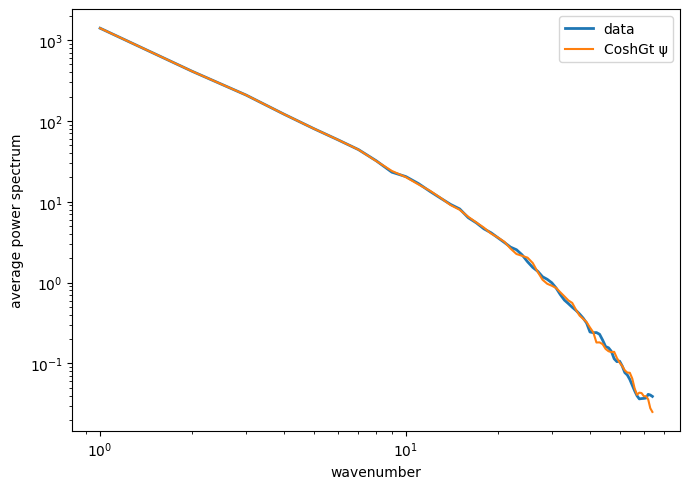

In [14]:
def plot_spectrum_overlay(x_ref, results, experiments):
    ps_ref = average_power_spectrum(x_ref)
    k = np.arange(len(ps_ref))

    plt.figure(figsize=(7, 5))
    plt.loglog(k[1:], ps_ref[1:], label='data', linewidth=2)
    for key, exp in experiments.items():
        ps = average_power_spectrum(results[key]['xt'])
        
        plt.loglog(k[1:], ps[1:], label=exp['label'])
    plt.xlabel('wavenumber')
    plt.ylabel('average power spectrum')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_spectrum_overlay(x1, results, experiments)


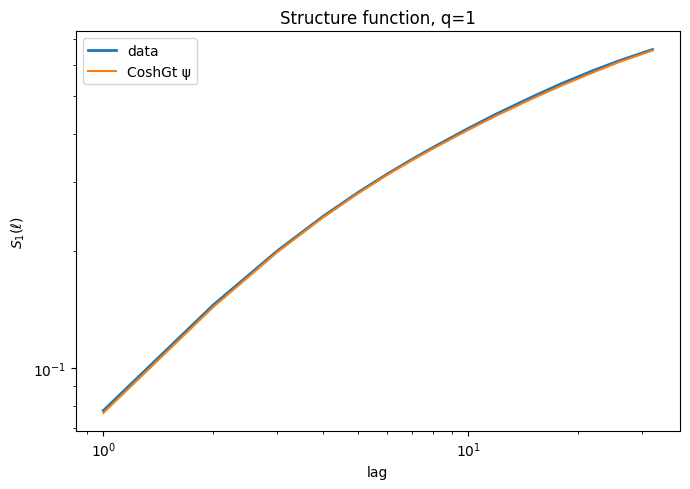

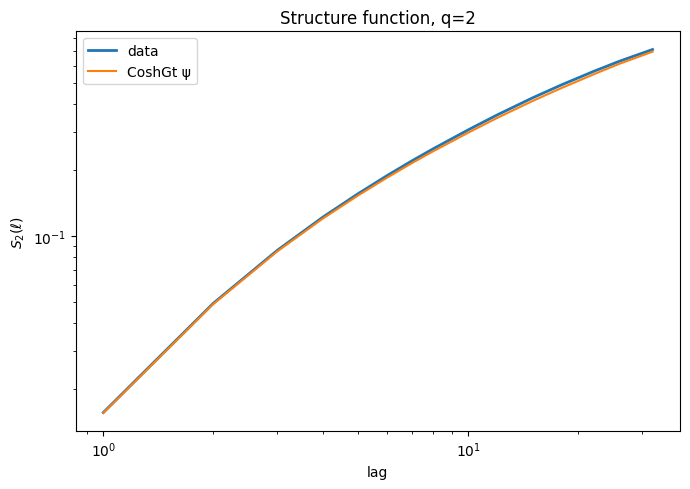

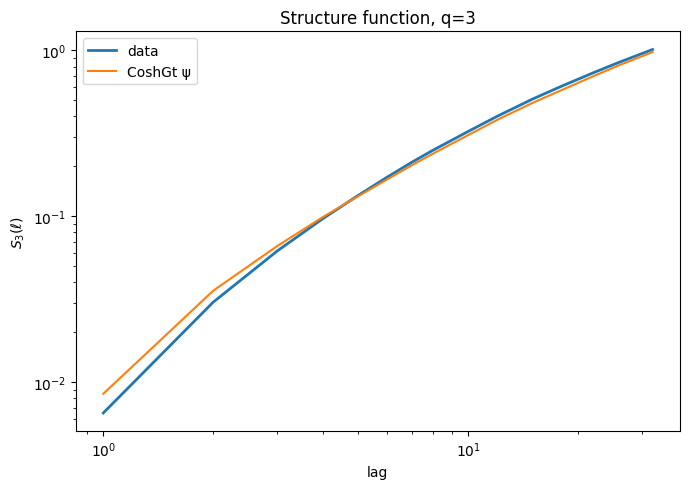

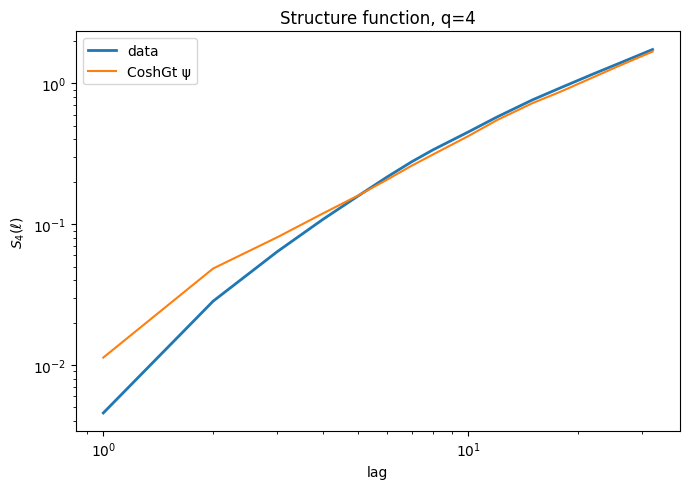

In [15]:
def plot_structure_overlay(x_ref, results, experiments, qs_to_plot=(1, 2, 3, 4)):
    qs, lags, sf_ref = structure_functions_np(x_ref, qs=qs_to_plot)

    for i, q in enumerate(qs):
        plt.figure(figsize=(7, 5))
        plt.loglog(lags, sf_ref[i], label='data', linewidth=2)
        for key, exp in experiments.items():
            _, _, sf = structure_functions_np(results[key]['xt'], qs=qs, lags=lags)
            plt.loglog(lags, sf[i], label=exp['label'])
        plt.xlabel('lag')
        plt.ylabel(rf'$S_{q}(\ell)$')
        plt.title(rf'Structure function, q={q}')
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_structure_overlay(x1, results, experiments, qs_to_plot=(1, 2, 3, 4))


## Entropy bound comparison

CoshGt ψ
  Entropy bound: -1193.032958984375
  Gaussian estimation: -60.50067138671875


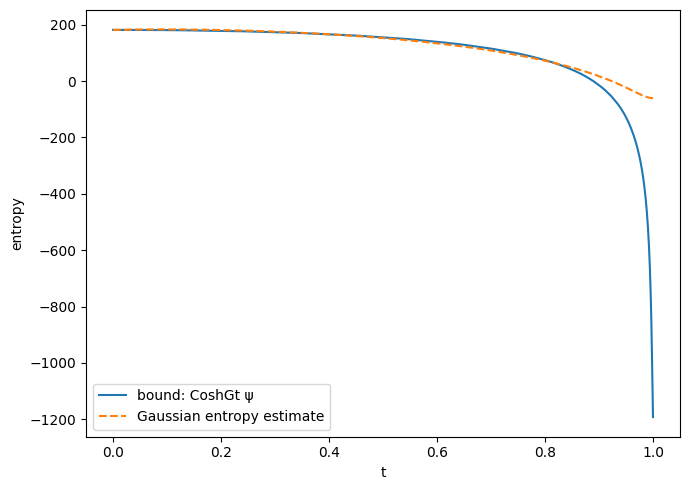

In [16]:
def entropy_curves(x_ref, dH_t_bound, t_used):
    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound = dH_t_bound.cumsum(0).detach().cpu() / nt + H_p_0
    H_t_gaussian = compute_gaussian_entropy(x_ref, interpolant, t_used)
    return H_t_bound, H_t_gaussian

plt.figure(figsize=(7, 5))
last_gaussian = None
for key, exp in experiments.items():
    H_t_bound, H_t_gaussian = entropy_curves(x1, results[key]['dH_t_bound'], results[key]['t'])
    last_gaussian = H_t_gaussian
    print(exp['label'])
    print('  Entropy bound:', H_t_bound[-1].item() if torch.is_tensor(H_t_bound[-1]) else H_t_bound[-1])
    print('  Gaussian estimation:', H_t_gaussian[-1].item() if torch.is_tensor(H_t_gaussian[-1]) else H_t_gaussian[-1])
    plt.plot(results[key]['t'].detach().cpu(), H_t_bound, label=f"bound: {exp['label']}")

plt.plot(
    t.detach().cpu(),
    last_gaussian.detach().cpu() if torch.is_tensor(last_gaussian) else last_gaussian,
    '--',
    label='Gaussian entropy estimate',
)
plt.xlabel('t')
plt.ylabel('entropy')
plt.legend()
plt.tight_layout()
plt.show()


## Project entropy plotting utility for each model